# Notebook 1: Neural Networks — Fundamentals & Applications
### Deep Learning Architecture (DLA) — Comprehensive Exam Preparation
**Sessions 2–7 · Supplementaries A, B, C, D**

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. **Derive** gradient descent from a first-order Taylor expansion and Newton's method from a second-order expansion
2. **Implement** a multilayer perceptron from scratch using only NumPy
3. **Trace** the backpropagation algorithm through a concrete numerical example
4. **Apply** neural networks to classification (binary & multi-class) and regression tasks
5. **Analyze** the effect of hyperparameters (learning rate, momentum, initialization) on training dynamics
6. **Explain** why each design choice matters — activations, loss functions, output layers

---

## Notebook Roadmap

| Part | Topic | Key Concepts |
|------|-------|-------------|
| 1 | Optimization Foundations | Gradient Descent, Newton's Method |
| 2 | Neural Network Architecture | Perceptrons, MLPs, Activation Functions |
| 3 | Backpropagation | Chain rule, weight updates, **numerical walkthrough** |
| 4 | Case 1 — Symmetry Classifier | Binary classification from scratch |
| 5 | Case 2 — State Classifier | Multi-class + softmax (college entrance) |
| 6 | Case 3 — Regressor | Function approximation (bike usage) |
| 7 | Case 4 — Differentiator & Integrator | NN as a calculus operator |
| 8 | Supplementaries A–D | Momentum, learning rate, initialization heuristics |

> **How to use this notebook:** Read the theory, study the code (comments explain every step), run the cells, then attempt the ✏️ **Exercises** and 🧠 **Exam Checkpoints** *before* revealing the hidden answers.


---
## Part 0 — Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Fix random seed for reproducibility — every run gives identical results
np.random.seed(42)

# Global plot styling for clean, readable figures
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
    'grid.alpha': 0.3
})
print("All imports ready.")


All imports ready.


---
## Part 1 — Optimization Foundations

Before we can build a neural network, we need to understand *how it learns*. Training a neural network boils down to one question: **how do we find the best weights?**

Formally, we want:

$$\mathbf{w}^* = \arg\min_{\mathbf{w}} \mathcal{L}(\mathbf{w})$$

where $\mathcal{L}$ is a loss function measuring how far our predictions are from the truth. We cannot solve this analytically for neural networks (the loss surface is non-convex and high-dimensional), so we rely on **iterative optimization**.

We start with two foundational methods — understanding their strengths and limitations will clarify *why* gradient descent became the workhorse of deep learning.

---

### 1.1 Gradient Descent

**Core Idea:** Stand on the loss surface, look around, and take a step in the direction that goes downhill the steepest.

**Update Rule:**

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \,\nabla \mathcal{L}(\mathbf{w}^{(t)})$$

where $\eta > 0$ is the **learning rate** — how big a step we take.

**Where does this come from?** Consider the first-order Taylor expansion of $\mathcal{L}$ around the current weights:

$$\mathcal{L}(\mathbf{w}^{(t)} + \Delta \mathbf{w}) \approx \mathcal{L}(\mathbf{w}^{(t)}) + \nabla \mathcal{L}(\mathbf{w}^{(t)})^\top \Delta \mathbf{w}$$

We want to choose $\Delta\mathbf{w}$ to *decrease* $\mathcal{L}$, which means we need $\nabla\mathcal{L}^\top \Delta\mathbf{w} < 0$. The direction that decreases $\mathcal{L}$ the fastest (per unit step) is:

$$\Delta \mathbf{w} = -\eta \,\nabla \mathcal{L}(\mathbf{w}^{(t)})$$

> 💡 **Intuition:** Imagine you're blindfolded on a hilly landscape. You can feel the slope beneath your feet (the gradient). To reach the valley, you step in the direction that slopes downward most steeply. The learning rate controls whether you take cautious baby steps or bold leaps.


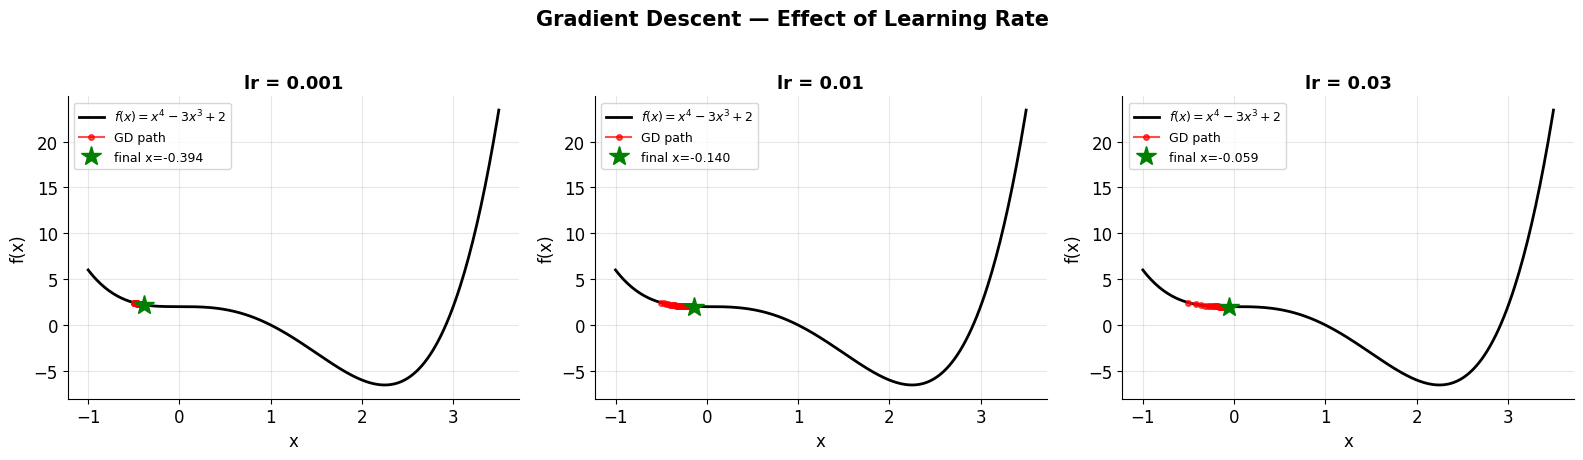

Observations:
  lr=0.001: Too slow — barely moves in 50 steps
  lr=0.01:  Moderate — steady progress toward minimum
  lr=0.03:  Fast convergence — but risks overshooting with larger lr


In [2]:
# ─── 1.1 Gradient Descent on a 1D function ───
# We use f(x) = x^4 - 3x^3 + 2, which has a clear global minimum around x ≈ 2.25

def f(x):
    """Our test function: a quartic with one local min and one global min."""
    return x**4 - 3*x**3 + 2

def df(x):
    """Analytical gradient: f'(x) = 4x^3 - 9x^2"""
    return 4*x**3 - 9*x**2

def gradient_descent_1d(f, df, x0, lr, n_steps):
    """
    Perform gradient descent on a 1D function.
    Returns the full trajectory so we can visualize the path.
    """
    trajectory = [x0]
    x = x0
    for _ in range(n_steps):
        grad = df(x)           # Step 1: compute gradient
        x = x - lr * grad      # Step 2: update in negative gradient direction
        trajectory.append(x)
    return np.array(trajectory)

# ─── Experiment: How does learning rate affect convergence? ───
x_plot = np.linspace(-1, 3.5, 300)  # x-axis for plotting the function
lrs = [0.001, 0.01, 0.03]           # three learning rates to compare

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, lr in zip(axes, lrs):
    traj = gradient_descent_1d(f, df, x0=-0.5, lr=lr, n_steps=50)
    
    # Plot the function curve
    ax.plot(x_plot, f(x_plot), 'k-', lw=2, label=r'$f(x)=x^4-3x^3+2$')
    # Overlay the GD trajectory (red dots connected by lines)
    ax.plot(traj, f(traj), 'ro-', ms=4, alpha=0.7, label='GD path')
    # Mark the final position with a green star
    ax.plot(traj[-1], f(traj[-1]), 'g*', ms=15, zorder=5, label=f'final x={traj[-1]:.3f}')
    
    ax.set_title(f'lr = {lr}', fontsize=13, fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(fontsize=9)

fig.suptitle('Gradient Descent — Effect of Learning Rate', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Key observations to note:
print("Observations:")
print("  lr=0.001: Too slow — barely moves in 50 steps")
print("  lr=0.01:  Moderate — steady progress toward minimum")
print("  lr=0.03:  Fast convergence — but risks overshooting with larger lr")


### 1.2 Newton's Method

Gradient descent only uses the *slope* (first derivative). But what if we also used the *curvature* (second derivative) to take smarter steps?

**Update Rule:**

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - [\mathbf{H}(\mathbf{w}^{(t)})]^{-1} \nabla \mathcal{L}(\mathbf{w}^{(t)})$$

where $\mathbf{H} = \nabla^2 \mathcal{L}$ is the **Hessian matrix** — the matrix of all second partial derivatives.

**Derivation from Second-Order Taylor Expansion:**

$$\mathcal{L}(\mathbf{w} + \Delta\mathbf{w}) \approx \mathcal{L}(\mathbf{w}) + \nabla\mathcal{L}^\top \Delta\mathbf{w} + \tfrac{1}{2} \Delta\mathbf{w}^\top \mathbf{H}\,\Delta\mathbf{w}$$

To find the best step, we set $\frac{\partial}{\partial \Delta\mathbf{w}} = 0$:

$$\nabla\mathcal{L} + \mathbf{H}\,\Delta\mathbf{w} = 0 \;\Longrightarrow\; \Delta\mathbf{w} = -\mathbf{H}^{-1}\nabla\mathcal{L}$$

> 💡 **Intuition:** Gradient descent knows *which way* is downhill, but not *how far* to go. Newton's method also knows the curvature — in a steep ravine it takes small steps, and on a gentle slope it takes large steps. This is why it converges much faster (quadratically vs. linearly).

> ⚠️ **The catch:** Computing the Hessian requires $O(n^2)$ storage and inverting it costs $O(n^3)$. For a network with millions of weights, this is completely impractical. This is *why we use gradient descent* in deep learning despite its slower convergence.

| Property | Gradient Descent | Newton's Method |
|----------|-----------------|-----------------|
| Info used | Gradient (1st order) | Gradient + Hessian (2nd order) |
| Convergence | Linear | Quadratic (near minimum) |
| Cost per step | $O(n)$ | $O(n^3)$ |
| Needs learning rate? | Yes | No (step size is built-in) |
| Practical for DNNs? | ✅ Yes | ❌ Too expensive |


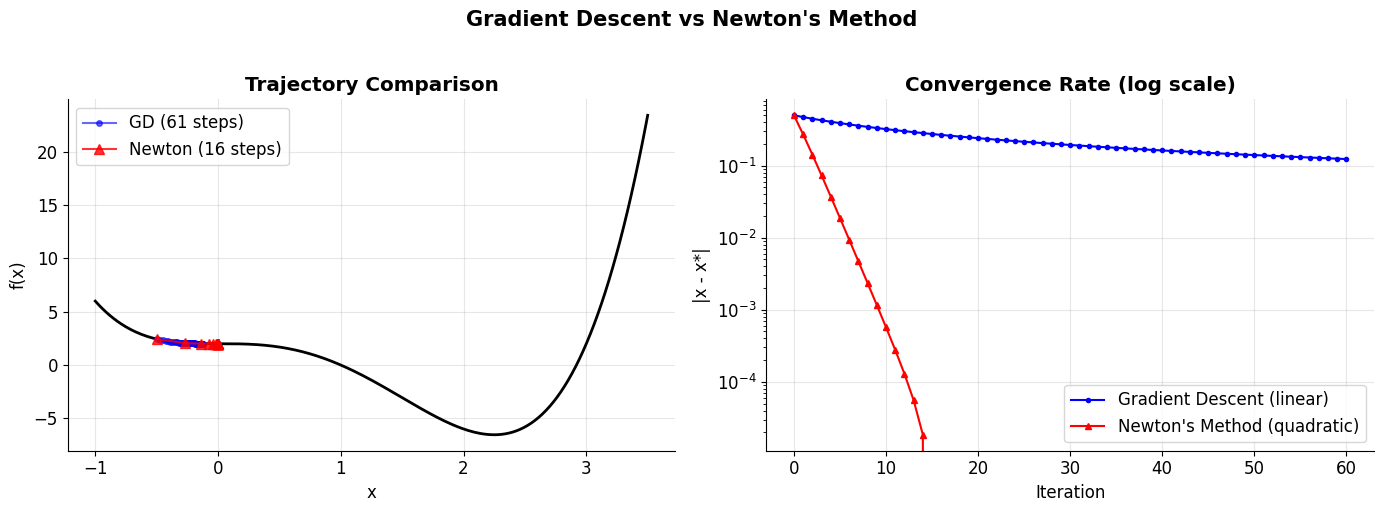

GD:     converged to x = -0.123606 in 61 steps
Newton: converged to x = -0.000018 in 16 steps

Notice: Newton reaches the minimum in ~5 steps; GD needs 60+ steps.
But Newton computes second derivatives — impractical for millions of weights.


In [3]:
# ─── 1.2 Newton's Method vs. Gradient Descent ───

def d2f(x):
    """Second derivative: f''(x) = 12x^2 - 18x"""
    return 12*x**2 - 18*x

def newtons_method_1d(f, df, d2f, x0, n_steps):
    """
    Newton's method in 1D: x_new = x - f'(x) / f''(x)
    No learning rate needed — the curvature determines step size.
    """
    trajectory = [x0]
    x = x0
    for _ in range(n_steps):
        hess = d2f(x)
        if abs(hess) < 1e-10:   # safety: avoid division by zero at inflection points
            break
        x = x - df(x) / hess   # Newton update: divide gradient by curvature
        trajectory.append(x)
    return np.array(trajectory)

# Run both methods from the same starting point
# Run both methods from the SAME starting point for fair comparison
traj_gd = gradient_descent_1d(f, df, x0=-0.5, lr=0.01, n_steps=60)
traj_newton = newtons_method_1d(f, df, d2f, x0=-0.5, n_steps=15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Overlay both trajectories on the function curve
ax1.plot(x_plot, f(x_plot), 'k-', lw=2)
ax1.plot(traj_gd, f(traj_gd), 'bo-', ms=4, alpha=0.6, label=f'GD ({len(traj_gd)} steps)')
ax1.plot(traj_newton, f(traj_newton), 'r^-', ms=7, alpha=0.8, label=f'Newton ({len(traj_newton)} steps)')
ax1.set_title('Trajectory Comparison', fontweight='bold')
ax1.set_xlabel('x'); ax1.set_ylabel('f(x)'); ax1.legend()

# RIGHT: Convergence rate — plot |x - x*| vs. iteration on log scale
# Linear convergence = straight line on log plot; quadratic = steep curve
x_star = traj_newton[-1]  # Newton converges fast; use its endpoint as approx minimum
gd_dist = np.abs(traj_gd - x_star)
newton_dist = np.abs(traj_newton - x_star)

ax2.semilogy(gd_dist, 'b-o', ms=3, label='Gradient Descent (linear)')
ax2.semilogy(newton_dist, 'r-^', ms=5, label="Newton's Method (quadratic)")
ax2.set_title('Convergence Rate (log scale)', fontweight='bold')
ax2.set_xlabel('Iteration'); ax2.set_ylabel('|x - x*|'); ax2.legend()

plt.suptitle("Gradient Descent vs Newton's Method", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"GD:     converged to x = {traj_gd[-1]:.6f} in {len(traj_gd)} steps")
print(f"Newton: converged to x = {traj_newton[-1]:.6f} in {len(traj_newton)} steps")
print()
print(f"Notice: Newton reaches the minimum in ~5 steps; GD needs 60+ steps.")
print("But Newton computes second derivatives — impractical for millions of weights.")


### 1.3 Gradient Descent on a 2D Surface

Real neural network loss landscapes are high-dimensional. To build intuition, let's visualize GD on a 2D function:

$$f(w_1, w_2) = w_1^2 + 5w_2^2$$

This **elliptical bowl** has different curvature along each axis — the $w_2$ direction is 5× steeper. This kind of asymmetry is *very common* in real loss surfaces, and it causes a characteristic problem: **zig-zagging**.

> 💡 **Why does GD zig-zag?** The gradient always points toward the steepest descent direction, which on an elongated bowl points mostly across the narrow direction rather than along the valley toward the minimum. The optimizer oscillates back and forth across the ravine while making slow progress along it. We'll see later how **momentum** fixes this.


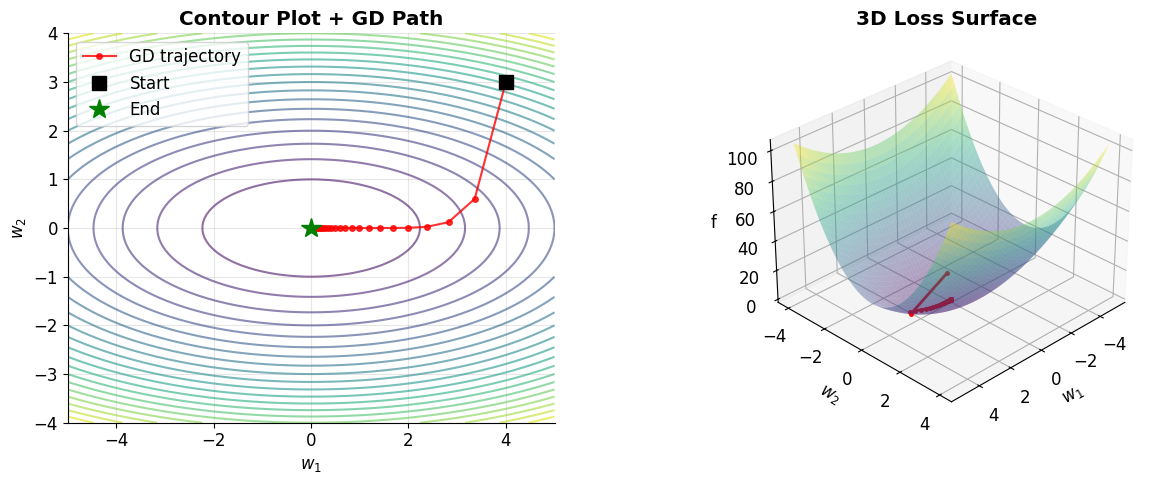

Start:  w = [4.0, 3.0],  f = 61.0
End:    w = [0.00374, 0.00000],  f = 0.00001

Notice the zig-zag pattern: GD oscillates across the steep w2 axis
while slowly creeping along the shallow w1 axis. Momentum will fix this.


In [4]:
# ─── 1.3 Gradient Descent on 2D Elliptical Bowl ───

def f_2d(w):
    """Elliptical bowl: different curvature along w1 (shallow) and w2 (steep)."""
    return w[0]**2 + 5*w[1]**2

def grad_2d(w):
    """Gradient: [2*w1, 10*w2] — note w2 gradient is 5x larger!"""
    return np.array([2*w[0], 10*w[1]])

def gd_2d(grad, w0, lr, n_steps):
    """2D gradient descent with trajectory recording."""
    traj = [w0.copy()]
    w = w0.copy()
    for _ in range(n_steps):
        w = w - lr * grad(w)    # same update rule, now in 2D
        traj.append(w.copy())
    return np.array(traj)

# Start from corner (4, 3) and descend toward origin (0, 0)
w0 = np.array([4.0, 3.0])
traj = gd_2d(grad_2d, w0, lr=0.08, n_steps=40)

fig = plt.figure(figsize=(14, 5))

# LEFT: Bird's-eye contour view with GD path
x1 = np.linspace(-5, 5, 100); x2 = np.linspace(-4, 4, 100)
X1, X2 = np.meshgrid(x1, x2); Z = X1**2 + 5*X2**2

ax1 = fig.add_subplot(121)
ax1.contour(X1, X2, Z, levels=20, cmap='viridis', alpha=0.6)
ax1.plot(traj[:,0], traj[:,1], 'ro-', ms=4, alpha=0.8, label='GD trajectory')
ax1.plot(traj[0,0], traj[0,1], 'ks', ms=10, label='Start')
ax1.plot(traj[-1,0], traj[-1,1], 'g*', ms=15, label='End')
ax1.set_title('Contour Plot + GD Path', fontweight='bold')
ax1.set_xlabel('$w_1$'); ax1.set_ylabel('$w_2$'); ax1.legend(); ax1.set_aspect('equal')

# RIGHT: 3D surface view
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.4, edgecolor='none')
ax2.plot(traj[:,0], traj[:,1], [f_2d(t) for t in traj], 'r.-', ms=5, lw=2)
ax2.set_title('3D Loss Surface', fontweight='bold')
ax2.set_xlabel('$w_1$'); ax2.set_ylabel('$w_2$'); ax2.set_zlabel('f')
ax2.view_init(elev=30, azim=45)

plt.tight_layout(); plt.show()

print(f"Start:  w = [{traj[0,0]:.1f}, {traj[0,1]:.1f}],  f = {f_2d(traj[0]):.1f}")
print(f"End:    w = [{traj[-1,0]:.5f}, {traj[-1,1]:.5f}],  f = {f_2d(traj[-1]):.5f}")
print()
print(f"Notice the zig-zag pattern: GD oscillates across the steep w2 axis")
print("while slowly creeping along the shallow w1 axis. Momentum will fix this.")


---

> 🧠 **Exam Checkpoint 1 — Optimization**
>
> Before continuing, make sure you can answer these:
>
> 1. Write the gradient descent update rule. What happens if $\eta$ is too large? Too small?
> 2. Derive the GD update from the first-order Taylor expansion of $\mathcal{L}$.
> 3. How does Newton's method differ? Write its update rule and explain why it's impractical for deep networks.
> 4. Why does GD zig-zag on an elliptical loss surface?
>
> <details><summary>Click to reveal key answers</summary>
>
> 1. $w \leftarrow w - \eta \nabla\mathcal{L}$. Too large → overshoots/diverges. Too small → converges very slowly, may get stuck.
> 2. $\mathcal{L}(w+\Delta w) \approx \mathcal{L}(w) + \nabla\mathcal{L}^\top\Delta w$. To minimize, set $\Delta w = -\eta\nabla\mathcal{L}$.
> 3. $w \leftarrow w - H^{-1}\nabla\mathcal{L}$. Hessian is $n \times n$, inversion is $O(n^3)$ — for $n = 10^6$ weights, this is infeasible.
> 4. The gradient points perpendicular to contours (steepest local descent), which on elongated bowls oscillates across the narrow axis rather than heading directly to the minimum.
> </details>


---
## Part 2 — Neural Network Architecture

Now that we know *how* to optimize, we need to define *what* we're optimizing. This section builds the neural network piece by piece.

---

### 2.1 The Artificial Neuron

A single neuron computes:

$$z = \sum_{i=1}^{n} w_i x_i + b = \mathbf{w}^\top \mathbf{x} + b \qquad \text{(pre-activation)}$$

$$a = \sigma(z) \qquad \text{(activation)}$$

The weights $w_i$ determine how much each input contributes, $b$ shifts the decision boundary, and $\sigma$ introduces nonlinearity.

### 2.2 Activation Functions — Why They Matter

Without a nonlinear activation, a stack of layers is just one big linear transformation:

$$W_2(W_1 \mathbf{x} + b_1) + b_2 = \underbrace{(W_2 W_1)}_{W'}\mathbf{x} + \underbrace{(W_2 b_1 + b_2)}_{b'}$$

No matter how many layers we add, the result is a single linear map $W'\mathbf{x} + b'$. This can only model linear relationships. **Nonlinear activations break this limitation** and allow neural networks to learn complex, curved decision boundaries.

| Function | Formula | Range | Derivative | When to use |
|----------|---------|-------|-----------|-------------|
| **Sigmoid** | $\frac{1}{1 + e^{-z}}$ | $(0,1)$ | $\sigma(1-\sigma)$ | Output of binary classifiers |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $(-1,1)$ | $1-\tanh^2$ | Hidden layers (zero-centered) |
| **ReLU** | $\max(0,z)$ | $[0,\infty)$ | $\mathbb{1}_{z>0}$ | Default for deep networks |
| **Leaky ReLU** | $\max(\alpha z, z)$ | $(-\infty,\infty)$ | $1$ or $\alpha$ | Prevents "dying ReLU" |

> ⚠️ **Common pitfall — Vanishing gradients:** Sigmoid and tanh saturate for large $|z|$, where their derivatives become nearly zero. In deep networks, this causes gradients to shrink exponentially as they propagate backward — weights in early layers barely update. This is the **vanishing gradient problem**, and it's why ReLU became the default for deep networks.


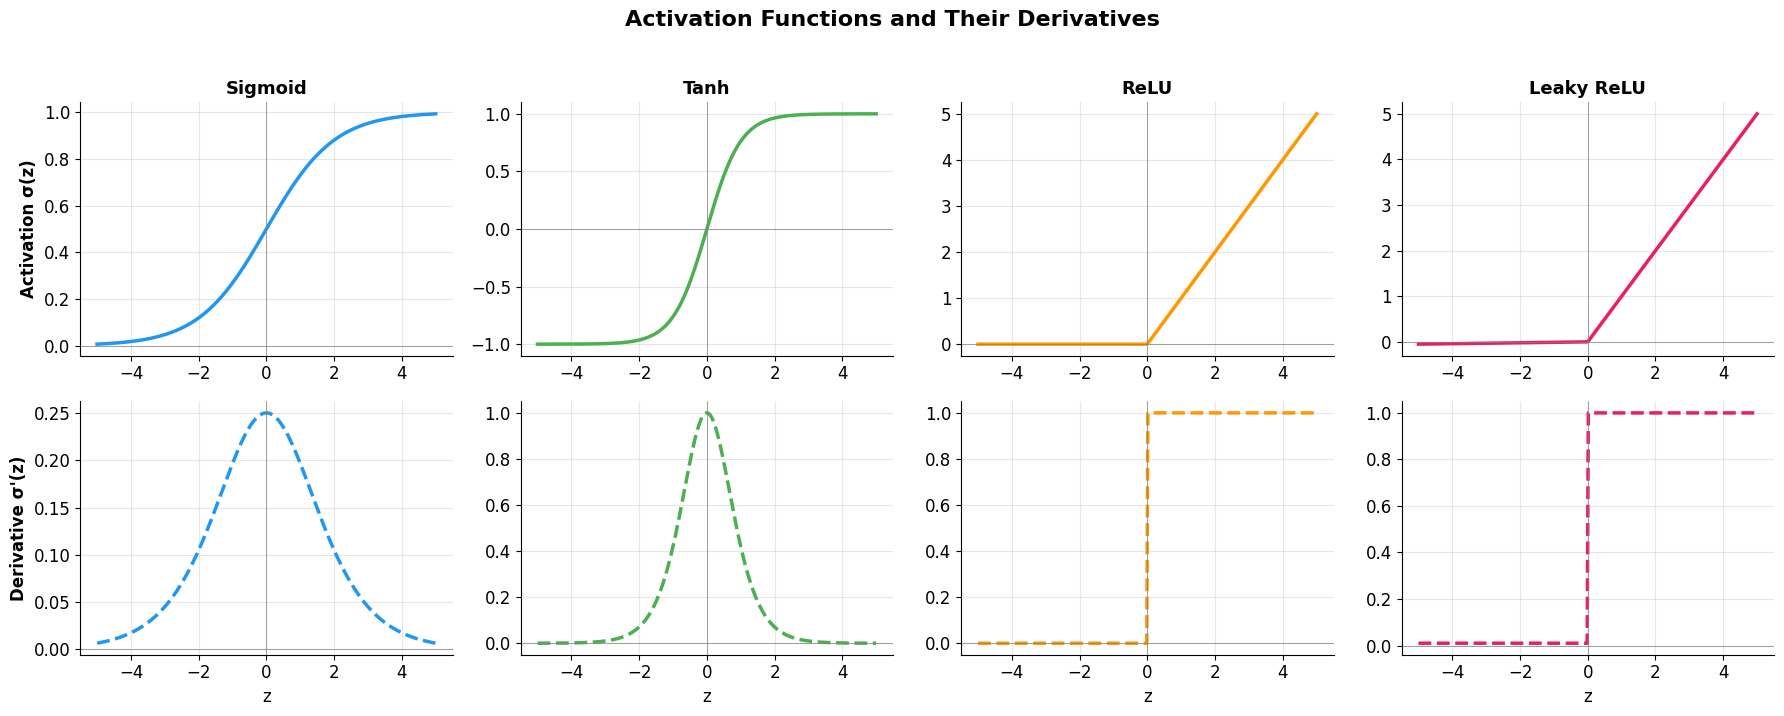

KEY OBSERVATIONS:
• Sigmoid derivative peaks at 0.25 — gradients are always ≤ 1/4 per layer!
  In a 10-layer net: 0.25^10 ≈ 0.000001 — vanishing gradients.
• Tanh derivative peaks at 1.0 — better than sigmoid but still saturates.
• ReLU derivative is exactly 1 for z > 0 — gradients flow without shrinking.
  But for z < 0, gradient is 0 — neuron is 'dead' and stops learning.
• Leaky ReLU fixes the dead neuron problem with a small slope (α=0.01).


In [5]:
# ─── 2.2 Activation Functions and Their Derivatives ───
# Understanding these shapes is critical: the derivative tells us how
# strongly the error signal flows backward during backpropagation.

def sigmoid(z):
    """Sigmoid squashes any value into (0, 1). Good for probabilities."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    """Key property: sigma'(z) = sigma(z) * (1 - sigma(z))
    Maximum at z=0 (value = 0.25), approaches 0 at extremes."""
    s = sigmoid(z)
    return s * (1 - s)

def tanh_act(z):
    """Tanh: zero-centered version of sigmoid. Outputs in (-1, 1)."""
    return np.tanh(z)

def tanh_deriv(z):
    """tanh'(z) = 1 - tanh(z)^2. Maximum at z=0 (value = 1)."""
    return 1 - np.tanh(z)**2

def relu(z):
    """ReLU: simple, fast, non-saturating for z > 0. But 'dies' for z < 0."""
    return np.maximum(0, z)

def relu_deriv(z):
    """ReLU derivative: 1 for z > 0, exactly 0 for z <= 0."""
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    """Leaky ReLU: small slope for z < 0 prevents dead neurons."""
    return np.where(z > 0, z, alpha * z)

def leaky_relu_deriv(z, alpha=0.01):
    """Leaky ReLU derivative: 1 for z > 0, alpha for z <= 0."""
    return np.where(z > 0, 1.0, alpha)

# ─── Plot all four activations with their derivatives ───
z = np.linspace(-5, 5, 300)
acts = [
    ('Sigmoid', sigmoid, sigmoid_deriv, '#2196F3'),
    ('Tanh', tanh_act, tanh_deriv, '#4CAF50'),
    ('ReLU', relu, relu_deriv, '#FF9800'),
    ('Leaky ReLU', leaky_relu, leaky_relu_deriv, '#E91E63'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, (name, act, deriv, color) in enumerate(acts):
    # Top row: activation function
    axes[0,i].plot(z, act(z), color=color, lw=2.5)
    axes[0,i].axhline(0, color='gray', lw=0.5); axes[0,i].axvline(0, color='gray', lw=0.5)
    axes[0,i].set_title(name, fontweight='bold', fontsize=13)
    
    # Bottom row: derivative (this is what flows backward in backprop!)
    axes[1,i].plot(z, deriv(z), color=color, lw=2.5, ls='--')
    axes[1,i].axhline(0, color='gray', lw=0.5); axes[1,i].axvline(0, color='gray', lw=0.5)
    axes[1,i].set_xlabel('z')

axes[0,0].set_ylabel('Activation σ(z)', fontweight='bold')
axes[1,0].set_ylabel("Derivative σ'(z)", fontweight='bold')
fig.suptitle('Activation Functions and Their Derivatives', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("KEY OBSERVATIONS:")
print("• Sigmoid derivative peaks at 0.25 — gradients are always ≤ 1/4 per layer!")
print("  In a 10-layer net: 0.25^10 ≈ 0.000001 — vanishing gradients.")
print("• Tanh derivative peaks at 1.0 — better than sigmoid but still saturates.")
print("• ReLU derivative is exactly 1 for z > 0 — gradients flow without shrinking.")
print("  But for z < 0, gradient is 0 — neuron is 'dead' and stops learning.")
print("• Leaky ReLU fixes the dead neuron problem with a small slope (α=0.01).")


### 2.3 Multilayer Perceptron (MLP)

An MLP connects neurons into layers. For layer $\ell$:

$$\mathbf{z}^{[\ell]} = \mathbf{W}^{[\ell]} \mathbf{a}^{[\ell-1]} + \mathbf{b}^{[\ell]} \qquad \text{(weighted sum)}$$
$$\mathbf{a}^{[\ell]} = \sigma^{[\ell]}(\mathbf{z}^{[\ell]}) \qquad \text{(activation)}$$

where:
- $\mathbf{a}^{[0]} = \mathbf{x}$ is the input
- $\mathbf{W}^{[\ell]} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$ connects layer $\ell-1$ to layer $\ell$
- Each column of $\mathbf{W}^{[\ell]}$ holds the weights *into* one neuron

> 💡 **Shape rule:** If layer $\ell-1$ has $n_{\ell-1}$ neurons and layer $\ell$ has $n_\ell$ neurons, then $\mathbf{W}^{[\ell]}$ is $n_\ell \times n_{\ell-1}$. This is the single most common source of shape bugs — always verify dimensions!

**Choosing the output activation depends on the task:**

| Task | Output activation | Output range | Loss function |
|------|------------------|-------------|---------------|
| Regression | Linear (identity) | $(-\infty, \infty)$ | MSE |
| Binary classification | Sigmoid | $(0, 1)$ | Binary Cross-Entropy |
| Multi-class classification | Softmax | $(0,1)^C$, sums to 1 | Categorical Cross-Entropy |


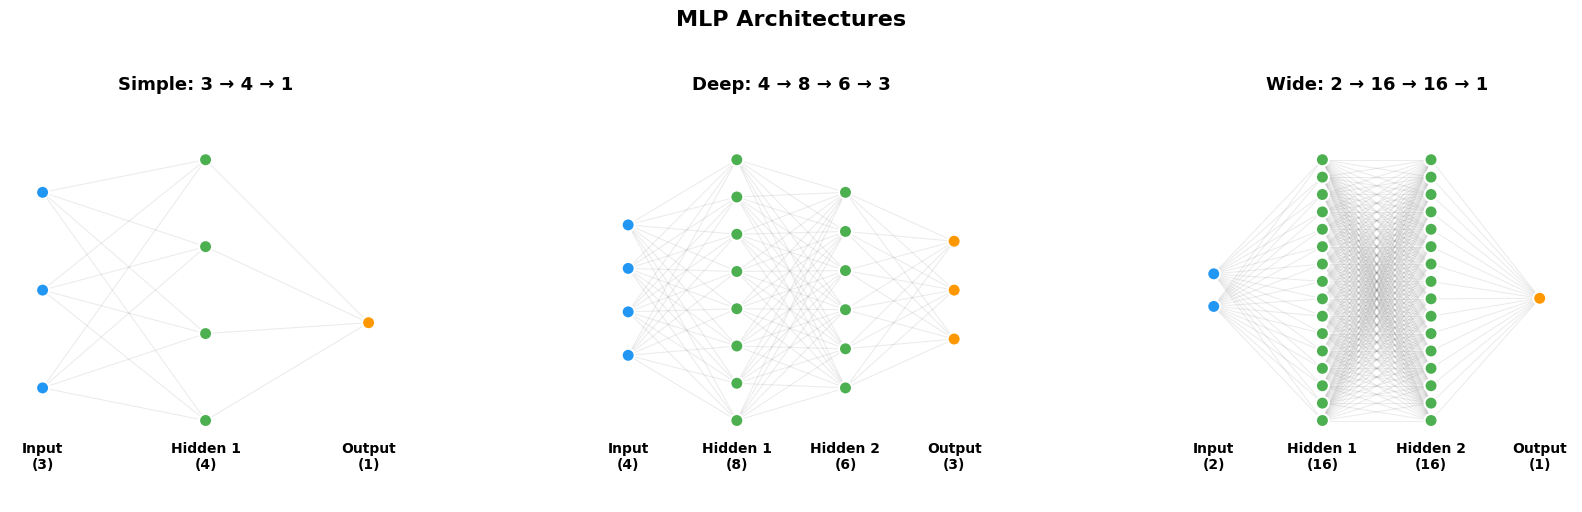

The Simple network (12 params) can learn simple boundaries.
The Deep network (107 params) can learn hierarchical features.
The Wide network (305 params) can memorize complex patterns,
  but more params also means higher risk of overfitting.


In [6]:
# ─── 2.3 Visualize MLP Architectures ───
# This helps build intuition about network capacity:
# wider layers = more features per level, deeper = more abstraction levels

def draw_mlp(layer_sizes, ax, title=""):
    """Draw a neural network diagram showing all connections."""
    n_layers = len(layer_sizes)
    max_n = max(layer_sizes)
    lx = np.linspace(0, 1, n_layers)  # x-positions for each layer
    
    # Compute neuron positions (vertically centered per layer)
    positions = []
    for i, n in enumerate(layer_sizes):
        ys = np.linspace(0.5 - 0.4*n/max_n, 0.5 + 0.4*n/max_n, n)
        positions.append([(lx[i], y) for y in ys])
    
    # Draw connections (lines between all neurons in adjacent layers)
    for i in range(n_layers - 1):
        for p1 in positions[i]:
            for p2 in positions[i+1]:
                ax.plot([p1[0],p2[0]], [p1[1],p2[1]], 'gray', alpha=0.15, lw=0.8)
    
    # Draw neurons (colored circles)
    colors = ['#2196F3','#4CAF50','#4CAF50','#FF9800']
    for i, (lpos, n) in enumerate(zip(positions, layer_sizes)):
        c = colors[-1] if i == n_layers-1 else colors[min(i, len(colors)-2)]
        for p in lpos:
            ax.add_patch(plt.Circle(p, 0.02, color=c, ec='white', lw=1.5, zorder=5))
        labels = {0:'Input', n_layers-1:'Output'}
        lbl = labels.get(i, f'Hidden {i}')
        ax.text(lx[i], -0.05, f'{lbl}\n({n})', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlim(-0.1,1.1); ax.set_ylim(-0.15,1.05)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
draw_mlp([3,4,1], axes[0], 'Simple: 3 → 4 → 1')
draw_mlp([4,8,6,3], axes[1], 'Deep: 4 → 8 → 6 → 3')
draw_mlp([2,16,16,1], axes[2], 'Wide: 2 → 16 → 16 → 1')
plt.suptitle('MLP Architectures', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("The Simple network (12 params) can learn simple boundaries.")
print("The Deep network (107 params) can learn hierarchical features.")
print("The Wide network (305 params) can memorize complex patterns,")
print("  but more params also means higher risk of overfitting.")


---
## Part 3 — Backpropagation: Full Derivation

Now that we know how the forward pass works (Part 2) and how to optimize with gradient descent (Part 1), the missing piece is: **how do we compute the gradients of the loss with respect to every weight in the network?**

Backpropagation answers this by computing $\frac{\partial \mathcal{L}}{\partial W^{[\ell]}}$ for every layer using the **chain rule**, propagating error signals backward from the output to the input.

### 3.1 Loss Functions

The loss measures how wrong our predictions are. Different tasks need different losses:

**Mean Squared Error** (regression):

$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

**Binary Cross-Entropy** (binary classification):

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

> 💡 **Why not use MSE for classification?** MSE penalizes all errors equally. But for classification, a confident wrong prediction (predicting 0.01 when truth is 1) should be punished *much more* than a slightly off prediction (0.4 when truth is 1). BCE does this — its gradient grows larger as the prediction gets more confidently wrong.

### 3.2 The Backpropagation Algorithm

For a network with $L$ layers:

**Step 1 — Output error** $\delta^{[L]}$:

For BCE+sigmoid or CCE+softmax, a beautiful cancellation gives:

$$\delta^{[L]} = \hat{y} - y$$

**Step 2 — Propagate error backward** (for each hidden layer $\ell = L-1, \ldots, 1$):

$$\delta^{[\ell]} = \big(\mathbf{W}^{[\ell+1]\top}\,\delta^{[\ell+1]}\big) \odot \sigma'(\mathbf{z}^{[\ell]})$$

> 💡 **Reading this equation:** The error at layer $\ell$ has two parts:
> 1. $\mathbf{W}^{[\ell+1]\top}\delta^{[\ell+1]}$ — the error from layer $\ell+1$, "pulled back" through the weights (how much did each neuron in layer $\ell$ *contribute* to the error above?)
> 2. $\odot\,\sigma'(\mathbf{z}^{[\ell]})$ — scaled by the activation derivative (if a neuron was in a flat region of sigmoid, it barely contributed, so it gets a small gradient)

**Step 3 — Compute gradients:**

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[\ell]}} = \delta^{[\ell]}\,(\mathbf{a}^{[\ell-1]})^\top, \qquad \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{[\ell]}} = \delta^{[\ell]}$$

**Step 4 — Update** (gradient descent):

$$\mathbf{W}^{[\ell]} \leftarrow \mathbf{W}^{[\ell]} - \eta\,\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{[\ell]}}$$

---

### 3.3 🔢 Worked Numerical Example

Let's trace backpropagation through a **concrete tiny network**: 2 inputs → 2 hidden → 1 output, with sigmoid activations and BCE loss.

This is the kind of exercise that frequently appears on comprehensive exams.


In [7]:
# ═══════════════════════════════════════════════════════════
# 3.3 WORKED NUMERICAL EXAMPLE — Trace every number!
# ═══════════════════════════════════════════════════════════
# Network: 2 → 2 → 1 (sigmoid everywhere, BCE loss)

print("=" * 65)
print("WORKED EXAMPLE: Backprop through a 2 → 2 → 1 network")
print("=" * 65)

# ── Given weights (small numbers for easy hand-calculation) ──
W1 = np.array([[0.1, 0.3],    # Layer 1 weights (2×2)
               [0.2, 0.4]])
b1 = np.array([[0.1],         # Layer 1 biases (2×1)
               [0.2]])
W2 = np.array([[0.5, 0.6]])   # Layer 2 weights (1×2)
b2 = np.array([[0.3]])        # Layer 2 bias (1×1)

# ── Input and true label ──
x = np.array([[1.0],          # Input (2×1)
              [0.5]])
y = np.array([[1.0]])         # True label: class 1

sig = lambda z: 1 / (1 + np.exp(-z))  # sigmoid

print()
print("── FORWARD PASS ──")
print(f"Input x = {x.flatten()}")

# Layer 1
z1 = W1 @ x + b1
a1 = sig(z1)
print()
print(f"Layer 1:")
print(f"  z1 = W1·x + b1 = {W1} @ {x.flatten()} + {b1.flatten()}")
print(f"     = {z1.flatten()}  (pre-activation)")
print(f"  a1 = sigmoid(z1) = {a1.flatten()}  (activation)")

# Layer 2 (output)
z2 = W2 @ a1 + b2
a2 = sig(z2)
y_hat = a2
print()
print(f"Layer 2 (output):")
print(f"  z2 = W2·a1 + b2 = {W2} @ {a1.flatten()} + {b2.flatten()}")
print(f"     = {z2.flatten()}")
print(f"  a2 = sigmoid(z2) = ŷ = {y_hat.flatten()[0]:.6f}")

# Loss
eps = 1e-12
loss = -(y * np.log(y_hat + eps) + (1-y) * np.log(1-y_hat + eps))
print()
print(f"BCE Loss = {loss.flatten()[0]:.6f}")

print()
print("── BACKWARD PASS ──")

# Step 1: Output error (BCE + sigmoid gives this clean form)
delta2 = a2 - y   # (ŷ - y)
print()
print(f"Step 1: Output error")
print(f"  δ2 = ŷ - y = {y_hat.flatten()[0]:.6f} - {y.flatten()[0]:.1f} = {delta2.flatten()[0]:.6f}")

# Step 2: Output layer gradients
dW2 = delta2 @ a1.T           # (1×1) @ (1×2) = (1×2)
db2 = delta2
print()
print(f"Step 2: Output layer gradients")
print(f"  dW2 = δ2 · a1ᵀ = {dW2.flatten()}")
print(f"  db2 = δ2 = {db2.flatten()}")

# Step 3: Backpropagate to hidden layer
sig_deriv_z1 = a1 * (1 - a1)  # σ'(z1)
delta1 = (W2.T @ delta2) * sig_deriv_z1  # (2×1) ⊙ (2×1)
print()
print(f"Step 3: Propagate error to hidden layer")
print(f"  σ'(z1) = a1 ⊙ (1-a1) = {sig_deriv_z1.flatten()}")
print(f"  δ1 = (W2ᵀ · δ2) ⊙ σ'(z1)")
print(f"     = ({(W2.T @ delta2).flatten()}) ⊙ ({sig_deriv_z1.flatten()})")
print(f"     = {delta1.flatten()}")

# Step 4: Hidden layer gradients
dW1 = delta1 @ x.T            # (2×1) @ (1×2) = (2×2)
db1 = delta1
print()
print(f"Step 4: Hidden layer gradients")
print(f"  dW1 = δ1 · xᵀ = ")
print(f"    {dW1}")
print(f"  db1 = δ1 = {db1.flatten()}")

# Step 5: Update (lr = 0.5)
lr = 0.5
W1_new = W1 - lr * dW1
W2_new = W2 - lr * dW2
print()
print(f"Step 5: Update weights (lr = {lr})")
print(f"  W1_new = W1 - {lr}·dW1 = ")
print(f"    {W1_new}")
print(f"  W2_new = W2 - {lr}·dW2 = {W2_new}")

# Verify: forward pass with new weights should give lower loss
z1_new = W1_new @ x + (b1 - lr*db1)
a1_new = sig(z1_new)
z2_new = W2_new @ a1_new + (b2 - lr*db2)
a2_new = sig(z2_new)
loss_new = -(y * np.log(a2_new + eps) + (1-y) * np.log(1-a2_new + eps))

print()
print(f"── VERIFICATION ──")
print(f"  Old prediction: ŷ = {y_hat.flatten()[0]:.6f}, Loss = {loss.flatten()[0]:.6f}")
print(f"  New prediction: ŷ = {a2_new.flatten()[0]:.6f}, Loss = {loss_new.flatten()[0]:.6f}")
print(f"  Loss decreased by {(loss - loss_new).flatten()[0]:.6f} ✓")


WORKED EXAMPLE: Backprop through a 2 → 2 → 1 network

── FORWARD PASS ──
Input x = [1.  0.5]

Layer 1:
  z1 = W1·x + b1 = [[0.1 0.3]
 [0.2 0.4]] @ [1.  0.5] + [0.1 0.2]
     = [0.35 0.6 ]  (pre-activation)
  a1 = sigmoid(z1) = [0.58661758 0.64565631]  (activation)

Layer 2 (output):
  z2 = W2·a1 + b2 = [[0.5 0.6]] @ [0.58661758 0.64565631] + [0.3]
     = [0.98070257]
  a2 = sigmoid(z2) = ŷ = 0.727248

BCE Loss = 0.318488

── BACKWARD PASS ──

Step 1: Output error
  δ2 = ŷ - y = 0.727248 - 1.0 = -0.272752

Step 2: Output layer gradients
  dW2 = δ2 · a1ᵀ = [-0.16000135 -0.17610431]
  db2 = δ2 = [-0.2727524]

Step 3: Propagate error to hidden layer
  σ'(z1) = a1 ⊙ (1-a1) = [0.2424974  0.22878424]
  δ1 = (W2ᵀ · δ2) ⊙ σ'(z1)
     = ([-0.1363762  -0.16365144]) ⊙ ([0.2424974  0.22878424])
     = [-0.03307087 -0.03744087]

Step 4: Hidden layer gradients
  dW1 = δ1 · xᵀ = 
    [[-0.03307087 -0.01653544]
 [-0.03744087 -0.01872044]]
  db1 = δ1 = [-0.03307087 -0.03744087]

Step 5: Update weights (


> ✏️ **Exercise 1 — Manual Backpropagation**
>
> Using the same 2→2→1 network above, trace the forward and backward passes with:
> - $x = [0.0, 1.0]^\top$, $y = 0$
> - Same initial weights
>
> Verify your $\delta^{[2]}$, $\delta^{[1]}$, and $\frac{\partial\mathcal{L}}{\partial W^{[1]}}$ by hand, then check with the code below.
>
> <details><summary>Click to reveal solution code</summary>
>
> ```python
> x_ex = np.array([[0.0], [1.0]]); y_ex = np.array([[0.0]])
> z1_ex = W1 @ x_ex + b1; a1_ex = sig(z1_ex)
> z2_ex = W2 @ a1_ex + b2; a2_ex = sig(z2_ex)
> delta2_ex = a2_ex - y_ex  # should be positive (predicted > 0 but truth is 0)
> delta1_ex = (W2.T @ delta2_ex) * (a1_ex * (1 - a1_ex))
> dW1_ex = delta1_ex @ x_ex.T
> print(f"delta2 = {delta2_ex.flatten()}, delta1 = {delta1_ex.flatten()}")
> print(f"dW1 = {dW1_ex}")
> ```
> </details>

---

### 3.4 Full MLP Implementation

Now we implement the complete MLP class. **Read the inline comments carefully** — they map each code line to the math above.


In [8]:
# ═══════════════════════════════════════════════════════════
# 3.4 FULL MLP CLASS — Pure NumPy
# ═══════════════════════════════════════════════════════════

class MLP:
    """
    Multilayer Perceptron built from scratch with NumPy.
    
    This implementation maps directly to the math in Section 3.2:
      - forward()  computes z[l] and a[l] for each layer
      - backward() computes delta[l], dW[l], db[l] via backprop
      - update()   applies gradient descent: W -= lr * dW
    
    Supports: sigmoid, tanh, relu, linear activations; mse, bce losses.
    """

    def __init__(self, layer_sizes, activations=None, loss='mse', seed=42):
        """
        Parameters
        ----------
        layer_sizes : list, e.g. [2, 8, 4, 1]
            Number of neurons per layer (including input and output).
        activations : list of str
            One per layer transition: ['tanh', 'tanh', 'sigmoid']
        loss : 'mse' or 'bce'
        """
        np.random.seed(seed)
        self.n_layers = len(layer_sizes)
        self.layer_sizes = layer_sizes
        self.loss_type = loss
        
        # Default: sigmoid everywhere (for backward compatibility)
        if activations is None:
            activations = ['sigmoid'] * (self.n_layers - 1)
        self.activations = activations

        # ── Weight initialization ──
        # Xavier init for sigmoid/tanh, He init for ReLU
        # This keeps activations from exploding or vanishing at the start
        self.weights, self.biases = [], []
        for i in range(1, self.n_layers):
            fan_in, fan_out = layer_sizes[i-1], layer_sizes[i]
            if self.activations[i-1] == 'relu':
                std = np.sqrt(2.0 / fan_in)           # He initialization
            else:
                std = np.sqrt(2.0 / (fan_in + fan_out))  # Xavier initialization
            
            W = np.random.randn(fan_out, fan_in) * std   # shape: (n_l, n_{l-1})
            b = np.zeros((fan_out, 1))                     # shape: (n_l, 1)
            self.weights.append(W)
            self.biases.append(b)
        
        self.training_loss = []

    # ── Activation functions ──
    def _act(self, z, name):
        """Apply activation function to pre-activation z."""
        if name == 'sigmoid': return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        if name == 'tanh':    return np.tanh(z)
        if name == 'relu':    return np.maximum(0, z)
        if name == 'linear':  return z

    def _act_d(self, z, name):
        """Compute activation derivative — this is sigma'(z) in the backprop equations."""
        if name == 'sigmoid': s = self._act(z,'sigmoid'); return s*(1-s)
        if name == 'tanh':    return 1 - np.tanh(z)**2
        if name == 'relu':    return (z > 0).astype(float)
        if name == 'linear':  return np.ones_like(z)

    # ── Forward pass (Section 2.3 equations) ──
    def forward(self, X):
        """
        Compute a[l] = sigma(W[l] @ a[l-1] + b[l]) for each layer.
        Caches z[l] and a[l] — these are needed for backprop.
        X shape: (n_features, n_samples)
        """
        self.a_cache = [X]  # a[0] = input
        self.z_cache = []
        a = X
        for i in range(self.n_layers - 1):
            z = self.weights[i] @ a + self.biases[i]   # z[l] = W[l] @ a[l-1] + b[l]
            a = self._act(z, self.activations[i])        # a[l] = sigma(z[l])
            self.z_cache.append(z)
            self.a_cache.append(a)
        return a  # final a = prediction

    # ── Loss computation ──
    def compute_loss(self, yp, yt):
        """Compute scalar loss value for monitoring."""
        if self.loss_type == 'mse':
            return np.mean((yp - yt)**2)
        else:  # bce
            eps = 1e-12
            yp = np.clip(yp, eps, 1-eps)
            return -np.mean(yt*np.log(yp) + (1-yt)*np.log(1-yp))

    # ── Backward pass (Section 3.2 equations) ──
    def backward(self, yt):
        """
        Backpropagation: compute dW[l] and db[l] for every layer.
        
        Key steps (mapping to Section 3.2):
          1. Compute output delta: delta[L] = a[L] - y  (for BCE+sigmoid)
          2. For each hidden layer l (going backward):
             delta[l] = (W[l+1].T @ delta[l+1]) * sigma'(z[l])
          3. dW[l] = (1/m) * delta[l] @ a[l-1].T
             db[l] = (1/m) * sum(delta[l], axis=1)
        """
        m = yt.shape[1]  # number of samples
        self.dW, self.db = [], []
        L = self.n_layers - 2  # index of last weight layer
        
        # ── Step 1: Output layer error ──
        if self.loss_type == 'bce' and self.activations[L] == 'sigmoid':
            # BCE + sigmoid: clean gradient (no separate sigma' needed)
            delta = self.a_cache[L+1] - yt
        elif self.loss_type == 'mse':
            # MSE: delta = 2(a-y)/m * sigma'(z)
            delta = 2*(self.a_cache[L+1] - yt)/m * self._act_d(self.z_cache[L], self.activations[L])
        else:
            delta = (self.a_cache[L+1] - yt) * self._act_d(self.z_cache[L], self.activations[L])
        
        # Weight and bias gradients for output layer
        self.dW.insert(0, (1/m) * delta @ self.a_cache[L].T)  # dW = delta @ a_prev.T
        self.db.insert(0, (1/m) * np.sum(delta, axis=1, keepdims=True))
        
        # ── Step 2: Hidden layers (propagate error backward) ──
        for l in range(L-1, -1, -1):
            # Pull error back through weights, scale by activation derivative
            delta = (self.weights[l+1].T @ delta) * self._act_d(self.z_cache[l], self.activations[l])
            self.dW.insert(0, (1/m) * delta @ self.a_cache[l].T)
            self.db.insert(0, (1/m) * np.sum(delta, axis=1, keepdims=True))

    # ── Weight update ──
    def update(self, lr):
        """Gradient descent: W[l] -= lr * dW[l]"""
        for i in range(len(self.weights)):
            self.weights[i] -= lr * self.dW[i]
            self.biases[i]  -= lr * self.db[i]

    # ── Training loop ──
    def fit(self, X, y, lr=0.01, epochs=1000, verbose=True, print_every=100):
        """
        Full training loop: forward → loss → backward → update, repeated.
        X: (n_features, n_samples), y: (n_outputs, n_samples)
        """
        self.training_loss = []
        for ep in range(epochs):
            yp = self.forward(X)              # 1. Forward pass
            loss = self.compute_loss(yp, y)    # 2. Compute loss
            self.training_loss.append(loss)
            self.backward(y)                   # 3. Backpropagation
            self.update(lr)                    # 4. Update weights
            
            if verbose and (ep % print_every == 0 or ep == epochs-1):
                print(f"  Epoch {ep:5d}/{epochs}  |  Loss: {loss:.6f}")
        return self.training_loss

    def predict(self, X):
        """Forward pass without caching (for inference)."""
        a = X
        for i in range(self.n_layers - 1):
            z = self.weights[i] @ a + self.biases[i]
            a = self._act(z, self.activations[i])
        return a

print("MLP class defined — ready for all 4 case studies.")
print("  .forward(X)   → prediction")
print("  .backward(y)  → computes gradients")
print("  .update(lr)   → gradient descent step")
print("  .fit(X,y,...) → full training loop")


MLP class defined — ready for all 4 case studies.
  .forward(X)   → prediction
  .backward(y)  → computes gradients
  .update(lr)   → gradient descent step
  .fit(X,y,...) → full training loop



> 🧠 **Exam Checkpoint 2 — Backpropagation**
>
> 1. In the backward pass, what does $\delta^{[\ell]}$ represent *physically*?
> 2. Why does BCE loss + sigmoid output give the clean gradient $\delta^{[L]} = \hat{y} - y$?
> 3. What is the computational complexity of one forward + backward pass?
> 4. If we used zero initialization ($W = 0$), what would happen during training?
>
> <details><summary>Click to reveal answers</summary>
>
> 1. $\delta^{[\ell]} = \frac{\partial\mathcal{L}}{\partial z^{[\ell]}}$ — it measures how much a small change in the pre-activation $z^{[\ell]}$ would affect the loss. It's the "error signal" at layer $\ell$.
> 2. The sigmoid derivative $\sigma'(z) = \sigma(z)(1-\sigma(z))$ and the BCE derivative $-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$ multiply together. When you expand: $(\frac{-y}{\sigma} + \frac{1-y}{1-\sigma}) \cdot \sigma(1-\sigma) = -y(1-\sigma) + (1-y)\sigma = \sigma - y = \hat{y} - y$.
> 3. $O(N)$ where $N$ is the total number of weights — each weight is visited a constant number of times in both passes. This is the key efficiency of backprop vs. numerically estimating each gradient separately ($O(N^2)$).
> 4. **Symmetry breaking problem:** All neurons in the same layer would compute identical values, receive identical gradients, and update identically. The network effectively has only 1 neuron per layer — it can never learn diverse features.
> </details>


---
## Part 4 — Case 1: Symmetry Classifier

Having built our MLP, let's apply it to a concrete problem. We start with binary classification.

**Task:** Given a binary input vector of length 6, classify whether it is **symmetric** (palindrome) or not.

| Input | Label |
|-------|-------|
| `[1,0,1,1,0,1]` | Symmetric ✓ |
| `[1,0,0,1,1,0]` | Not Symmetric ✗ |

**Why this problem is interesting:**

A linear classifier cannot solve this. Symmetry requires checking if $x_0 = x_5$, $x_1 = x_4$, and $x_2 = x_3$ — these are *pairwise comparisons* that are inherently nonlinear. The hidden layer must learn to compute something like XNOR gates between mirrored positions.

**Design choices:**
- **Architecture:** 6 → 12 → 8 → 1 (enough capacity for the 6-bit pattern)
- **Hidden activation:** Tanh (zero-centered, helps with symmetric inputs)
- **Output activation:** Sigmoid (binary classification → output is a probability)
- **Loss:** BCE (standard for binary classification)


In [9]:
# ─── Case 1: Generate the Symmetry Dataset ───
# We create balanced classes: 50% symmetric, 50% non-symmetric

def generate_symmetry_data(n_bits=6, n_samples=500):
    """
    Generate binary vectors and label them as symmetric (1) or not (0).
    A symmetric vector reads the same forwards and backwards (palindrome).
    """
    X, y = [], []
    half = n_bits // 2
    
    # Build all possible symmetric patterns (mirror the first half)
    sym_patterns = []
    for i in range(2**half):
        bits = list(map(int, format(i, f"0{half}b")))
        if n_bits % 2 == 0:
            sym_patterns.append(bits + bits[::-1])  # e.g. [1,0,1] → [1,0,1,1,0,1]
        else:
            for mid in [0, 1]:  # odd-length: middle bit can be 0 or 1
                sym_patterns.append(bits + [mid] + bits[::-1])

    # Sample symmetric examples (class 1)
    n_sym = n_samples // 2
    for _ in range(n_sym):
        X.append(sym_patterns[np.random.randint(len(sym_patterns))])
        y.append(1)
    
    # Sample non-symmetric examples (class 0) — reject if accidentally symmetric
    count = 0
    while count < n_samples - n_sym:
        vec = np.random.randint(0, 2, n_bits).tolist()
        if vec != vec[::-1]:  # only keep truly non-symmetric vectors
            X.append(vec); y.append(0); count += 1

    # Convert to arrays and shuffle
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(1, -1)
    perm = np.random.permutation(X.shape[0])
    return X[perm].T, y[:, perm]   # shapes: (6, N) and (1, N)

X_sym, y_sym = generate_symmetry_data(n_bits=6, n_samples=600)

print(f"Dataset shape:  X = {X_sym.shape},  y = {y_sym.shape}")
print(f"Class balance:  {int(y_sym.sum())} symmetric,  {int((1-y_sym).sum())} non-symmetric")
print(f"\nSample inputs:")
for i in range(6):
    v = X_sym[:, i].astype(int)
    lbl = "Symmetric ✓" if y_sym[0, i] == 1 else "Not Sym   ✗"
    mirror = "==" if list(v) == list(v[::-1]) else "!="
    print(f"  {v}  {mirror} reversed → {lbl}")


Dataset shape:  X = (6, 600),  y = (1, 600)
Class balance:  300 symmetric,  300 non-symmetric

Sample inputs:
  [0 0 1 1 0 0]  == reversed → Symmetric ✓
  [0 1 0 0 1 0]  == reversed → Symmetric ✓
  [1 0 0 0 0 1]  == reversed → Symmetric ✓
  [1 0 0 0 0 1]  == reversed → Symmetric ✓
  [1 1 0 0 1 1]  == reversed → Symmetric ✓
  [0 1 1 1 1 1]  != reversed → Not Sym   ✗


In [10]:
# ─── Case 1: Train the Symmetry Classifier ───

# Split: 80% train, 20% test
n_train = 480
X_tr_s, X_te_s = X_sym[:, :n_train], X_sym[:, n_train:]
y_tr_s, y_te_s = y_sym[:, :n_train], y_sym[:, n_train:]

# Build the network
model_sym = MLP(
    layer_sizes=[6, 12, 8, 1],     # 6 inputs → 12 hidden → 8 hidden → 1 output
    activations=['tanh', 'tanh', 'sigmoid'],  # tanh in hidden, sigmoid for binary output
    loss='bce',                     # binary cross-entropy
    seed=42
)

print("Training Symmetry Classifier")
print("Architecture: 6 → 12 → 8 → 1")
print("Hidden: Tanh  |  Output: Sigmoid  |  Loss: BCE")
print(f"Parameters: {sum(w.size + b.size for w, b in zip(model_sym.weights, model_sym.biases))}")
print()

losses_s = model_sym.fit(X_tr_s, y_tr_s, lr=0.5, epochs=3000, print_every=500)

# Evaluate on both sets
yp_tr = model_sym.predict(X_tr_s)
yp_te = model_sym.predict(X_te_s)
acc_tr = np.mean((yp_tr > 0.5) == y_tr_s) * 100
acc_te = np.mean((yp_te > 0.5) == y_te_s) * 100

print(f"\nTrain Accuracy: {acc_tr:.1f}%")
print(f"Test Accuracy:  {acc_te:.1f}%")
if acc_te > 95:
    print("The network successfully learned the symmetry pattern!")
elif acc_te > 80:
    print("Decent, but try more epochs or adjust architecture.")
else:
    print("Model is struggling — consider a wider hidden layer.")


Training Symmetry Classifier
Architecture: 6 → 12 → 8 → 1
Hidden: Tanh  |  Output: Sigmoid  |  Loss: BCE
Parameters: 197

  Epoch     0/3000  |  Loss: 0.703208


  Epoch   500/3000  |  Loss: 0.008067


  Epoch  1000/3000  |  Loss: 0.002593


  Epoch  1500/3000  |  Loss: 0.001492


  Epoch  2000/3000  |  Loss: 0.001034


  Epoch  2500/3000  |  Loss: 0.000786


  Epoch  2999/3000  |  Loss: 0.000631

Train Accuracy: 100.0%
Test Accuracy:  100.0%
The network successfully learned the symmetry pattern!


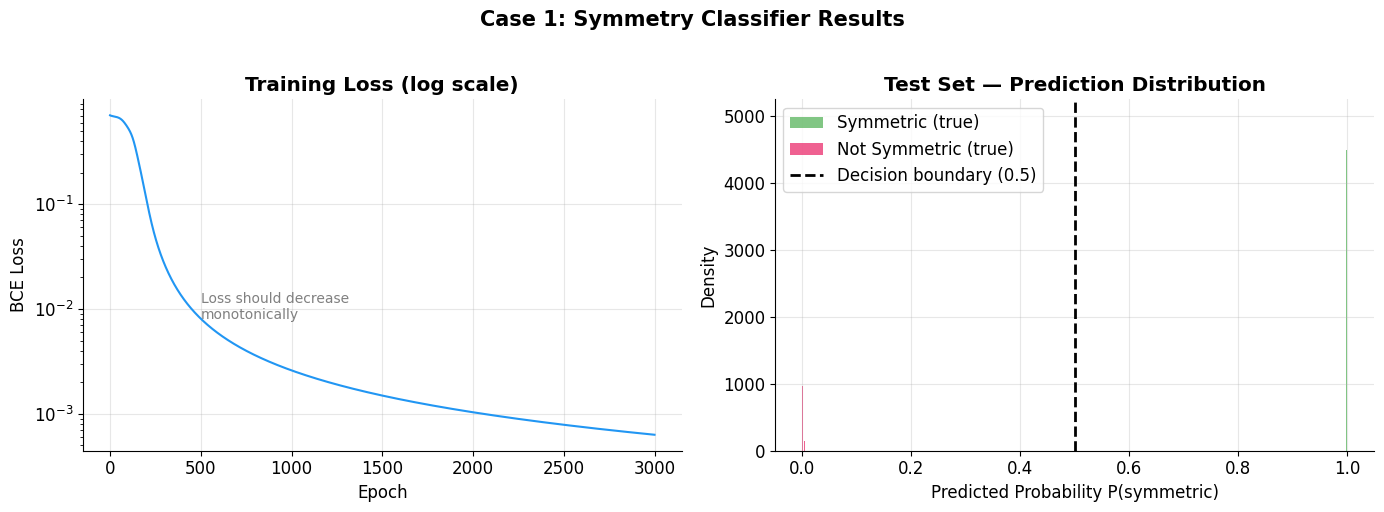

A good classifier pushes symmetric predictions toward 1.0
and non-symmetric predictions toward 0.0, with clear separation.


In [11]:
# ─── Case 1: Visualize Results ───

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Training loss curve — should decrease smoothly
ax1.plot(losses_s, color='#2196F3', lw=1.5)
ax1.set_yscale('log')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Training Loss (log scale)', fontweight='bold')
ax1.annotate('Loss should decrease\nmonotonically', xy=(500, losses_s[500]),
            fontsize=10, color='gray')

# RIGHT: How well does the model separate the two classes?
ax2.hist(yp_te[0, y_te_s[0]==1], bins=20, alpha=0.7, color='#4CAF50',
         label='Symmetric (true)', density=True)
ax2.hist(yp_te[0, y_te_s[0]==0], bins=20, alpha=0.7, color='#E91E63',
         label='Not Symmetric (true)', density=True)
ax2.axvline(0.5, color='k', ls='--', lw=2, label='Decision boundary (0.5)')
ax2.set_xlabel('Predicted Probability P(symmetric)')
ax2.set_ylabel('Density')
ax2.set_title('Test Set — Prediction Distribution', fontweight='bold')
ax2.legend()

plt.suptitle('Case 1: Symmetry Classifier Results', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("A good classifier pushes symmetric predictions toward 1.0")
print("and non-symmetric predictions toward 0.0, with clear separation.")



> ✏️ **Exercise 2 — Experiment with Architecture**
>
> Try these modifications and observe the effect:
> 1. **Reduce** the hidden layers to just `[6, 4, 1]` — can a smaller network still learn symmetry?
> 2. **Replace** tanh with ReLU — does it converge faster or slower?
> 3. **Change** to 8-bit inputs — does the same architecture still work?
>
> <details><summary>Hints</summary>
>
> - For (1): 6→4→1 might struggle since it has fewer parameters to learn 3 pairwise comparisons
> - For (2): ReLU may need a smaller learning rate (try 0.1 instead of 0.5) since it doesn't saturate
> - For (3): With 8 bits, there are 4 pairwise checks — you may need a wider hidden layer
> </details>


---
## Part 5 — Case 2: State Classifier (College Entrance)

Building on binary classification, we now tackle **multi-class classification** with 3 output classes.

**Task:** Given student features (exam scores, study hours, GPA, attendance), predict whether a student will **Pass**, **Conditional**, or **Fail** their college entrance test.

### Softmax — Generalizing Sigmoid to Multiple Classes

For $C$ classes, **softmax** converts raw network outputs (logits) into a valid probability distribution:

$$\hat{y}_c = \text{softmax}(z_c) = \frac{e^{z_c}}{\sum_{j=1}^{C} e^{z_j}}$$

Key properties:
- All outputs are in $(0, 1)$
- They sum to exactly 1: $\sum_c \hat{y}_c = 1$
- The class with the largest logit gets the highest probability

> 💡 **Connection to sigmoid:** For $C = 2$, softmax reduces to sigmoid! If we have logits $[z_1, z_2]$, then $\text{softmax}(z_1) = \frac{e^{z_1}}{e^{z_1} + e^{z_2}} = \frac{1}{1 + e^{-(z_1 - z_2)}} = \sigma(z_1 - z_2)$.

With **categorical cross-entropy** loss, the output error takes the same elegant form:

$$\delta^{[L]} = \hat{y} - y_{\text{one-hot}}$$


In [12]:
# ─── Case 2: Generate Synthetic College Entrance Data ───

def generate_college_data(n=600, seed=42):
    """
    Create synthetic student data with 4 features:
      - exam_score:  standardized test score (mean 65, std 15)
      - study_hours: weekly study hours (mean 20, std 8)
      - gpa:         grade point average (mean 2.5, std 0.7)
      - attendance:  class attendance percentage (mean 75, std 15)
    
    Labels: 0=Fail, 1=Conditional, 2=Pass (based on a weighted composite score)
    """
    np.random.seed(seed)
    
    # Generate realistic features
    exam   = np.random.normal(65, 15, n)
    hours  = np.random.normal(20, 8, n)
    gpa    = np.random.normal(2.5, 0.7, n)
    attend = np.random.normal(75, 15, n)
    
    # Composite score (weighted combination + noise for realistic uncertainty)
    comp = (0.35*exam + 0.25*hours*2.5 + 0.25*gpa*20 + 0.15*attend
            + np.random.normal(0, 5, n))
    
    # Thresholds determine class boundaries
    labels = np.zeros(n, dtype=int)
    labels[comp > 55] = 1    # Conditional
    labels[comp > 72] = 2    # Pass
    
    # Stack and normalize features (zero mean, unit variance)
    X = np.vstack([exam, hours, gpa, attend])
    X = (X - X.mean(1, keepdims=True)) / (X.std(1, keepdims=True) + 1e-8)
    
    return X, labels

X_col, y_col_lbl = generate_college_data()

print(f"Features shape: {X_col.shape}  (4 features × 600 students)")
print(f"Class distribution:")
print(f"  Fail:        {np.sum(y_col_lbl==0)} students")
print(f"  Conditional: {np.sum(y_col_lbl==1)} students")
print(f"  Pass:        {np.sum(y_col_lbl==2)} students")


Features shape: (4, 600)  (4 features × 600 students)
Class distribution:
  Fail:        188 students
  Conditional: 351 students
  Pass:        61 students


In [13]:
# ─── Case 2: MLP with Softmax Output ───

class MLPSoftmax(MLP):
    """
    Extends MLP with softmax output layer + categorical cross-entropy.
    
    The key difference from binary MLP:
      - Output: softmax instead of sigmoid
      - Loss: CCE instead of BCE
      - Labels: one-hot encoded (e.g., class 2 → [0, 0, 1])
    
    The backward pass is almost identical — the beautiful result
    delta[L] = y_hat - y_onehot holds for softmax+CCE too!
    """

    def __init__(self, layer_sizes, activations=None, seed=42):
        super().__init__(layer_sizes, activations, loss='cce', seed=seed)

    def _softmax(self, z):
        """Numerically stable softmax: subtract max before exp to prevent overflow."""
        e = np.exp(z - z.max(0, keepdims=True))  # shift for stability
        return e / e.sum(0, keepdims=True)         # normalize to sum to 1

    def forward(self, X):
        """Forward pass: hidden layers use standard activations, output uses softmax."""
        self.a_cache, self.z_cache = [X], []
        a = X
        # Hidden layers: standard activation (tanh, relu, etc.)
        for i in range(self.n_layers - 2):
            z = self.weights[i] @ a + self.biases[i]
            a = self._act(z, self.activations[i])
            self.z_cache.append(z); self.a_cache.append(a)
        # Output layer: softmax
        z = self.weights[-1] @ a + self.biases[-1]
        a = self._softmax(z)
        self.z_cache.append(z); self.a_cache.append(a)
        return a

    def compute_loss(self, yp, yt):
        """Categorical cross-entropy: -mean(sum(y_onehot * log(y_pred)))"""
        return -np.mean(np.sum(yt * np.log(yp + 1e-12), axis=0))

    def backward(self, yt):
        """Backprop with softmax+CCE: output delta = y_hat - y_onehot (same clean form!)"""
        m = yt.shape[1]
        self.dW, self.db = [], []
        L = self.n_layers - 2
        
        # Output error: clean gradient (same form as BCE+sigmoid!)
        delta = self.a_cache[L+1] - yt
        self.dW.insert(0, (1/m) * delta @ self.a_cache[L].T)
        self.db.insert(0, (1/m) * np.sum(delta, axis=1, keepdims=True))
        
        # Propagate backward through hidden layers
        for l in range(L-1, -1, -1):
            delta = (self.weights[l+1].T @ delta) * self._act_d(self.z_cache[l], self.activations[l])
            self.dW.insert(0, (1/m) * delta @ self.a_cache[l].T)
            self.db.insert(0, (1/m) * np.sum(delta, axis=1, keepdims=True))

    def predict(self, X):
        """Forward pass without caching."""
        a = X
        for i in range(self.n_layers - 2):
            z = self.weights[i] @ a + self.biases[i]
            a = self._act(z, self.activations[i])
        z = self.weights[-1] @ a + self.biases[-1]
        return self._softmax(z)


# ── Helper: one-hot encoding ──
def one_hot(labels, C):
    """Convert integer labels [0,1,2,...] to one-hot matrix (C × N)."""
    oh = np.zeros((C, len(labels)))
    oh[labels, np.arange(len(labels))] = 1
    return oh

# ── Prepare data ──
y_oh = one_hot(y_col_lbl, 3)  # shape: (3, 600)
nc = 480
X_tr_c, X_te_c = X_col[:, :nc], X_col[:, nc:]
y_tr_c, y_te_c = y_oh[:, :nc], y_oh[:, nc:]
y_te_lbl = y_col_lbl[nc:]

# ── Train ──
model_col = MLPSoftmax(
    layer_sizes=[4, 16, 12, 3],     # 4 features → 16 → 12 → 3 classes
    activations=['tanh', 'tanh', 'softmax'],
    seed=42
)

print("Training State Classifier")
print("Architecture: 4 → 16 → 12 → 3 (softmax)")
print("Loss: Categorical Cross-Entropy\n")

losses_c = model_col.fit(X_tr_c, y_tr_c, lr=0.3, epochs=2000, print_every=400)

# ── Evaluate ──
yp_c = model_col.predict(X_te_c)
pred_lbl = np.argmax(yp_c, axis=0)  # class = argmax of probabilities
test_acc = np.mean(pred_lbl == y_te_lbl) * 100
print(f"\nTest Accuracy: {test_acc:.1f}%")


Training State Classifier
Architecture: 4 → 16 → 12 → 3 (softmax)
Loss: Categorical Cross-Entropy

  Epoch     0/2000  |  Loss: 1.244252
  Epoch   400/2000  |  Loss: 0.447885


  Epoch   800/2000  |  Loss: 0.431271


  Epoch  1200/2000  |  Loss: 0.409087
  Epoch  1600/2000  |  Loss: 0.372956


  Epoch  1999/2000  |  Loss: 0.327896

Test Accuracy: 74.2%


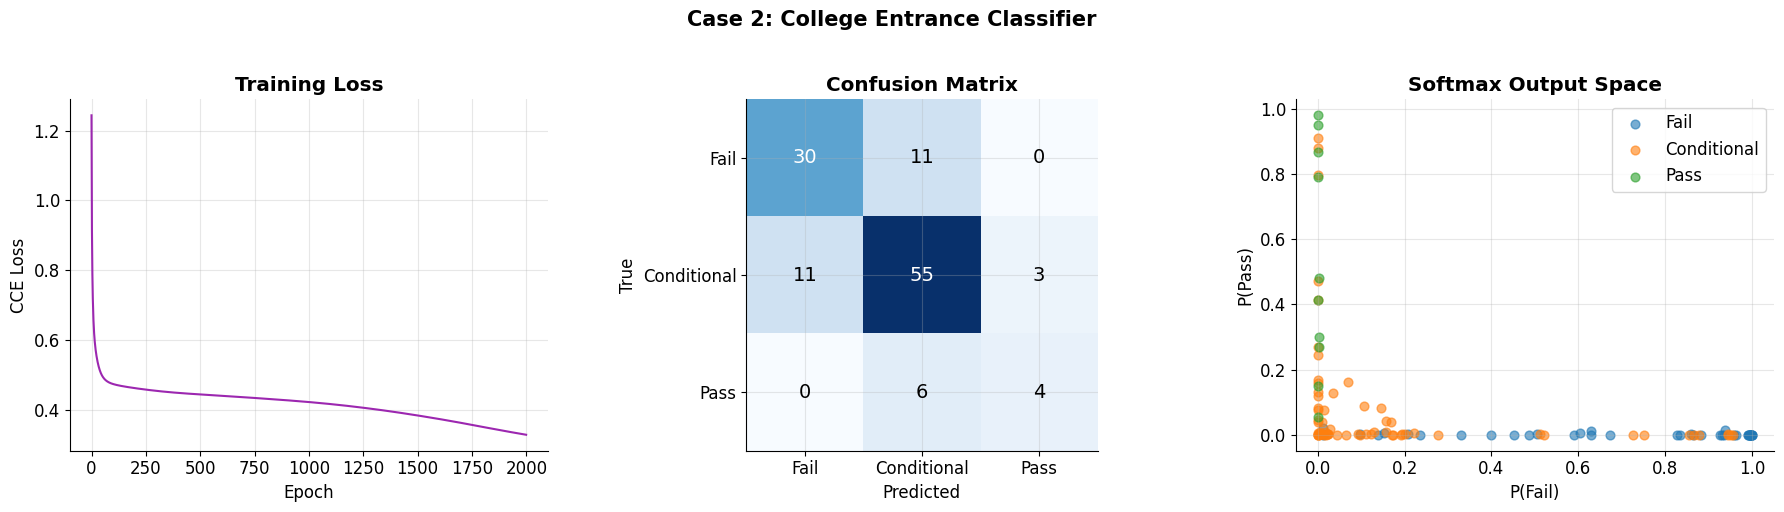

Per-class accuracy:
  Fail        : 73.2% (30/41 correct)
  Conditional : 79.7% (55/69 correct)
  Pass        : 40.0% (4/10 correct)


In [14]:
# ─── Case 2: Comprehensive Visualization ───

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Training loss
axes[0].plot(losses_c, color='#9C27B0', lw=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CCE Loss')
axes[0].set_title('Training Loss', fontweight='bold')

# CENTER: Confusion matrix — shows where the model gets confused
names = ['Fail', 'Conditional', 'Pass']
conf = np.zeros((3, 3), dtype=int)
for t, p in zip(y_te_lbl, pred_lbl):
    conf[t, p] += 1  # conf[true, predicted]

im = axes[1].imshow(conf, cmap='Blues')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(conf[i,j]), ha='center', va='center', fontsize=14,
                    color='white' if conf[i,j] > conf.max()/2 else 'black')
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(names); axes[1].set_yticklabels(names)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix', fontweight='bold')

# RIGHT: Softmax output space — each point is a test student
for c in range(3):
    mask = y_te_lbl == c
    axes[2].scatter(yp_c[0, mask], yp_c[2, mask], alpha=0.6, s=40, label=names[c])
axes[2].set_xlabel('P(Fail)'); axes[2].set_ylabel('P(Pass)')
axes[2].set_title('Softmax Output Space', fontweight='bold')
axes[2].legend()

plt.suptitle('Case 2: College Entrance Classifier', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Per-class accuracy
print("Per-class accuracy:")
for c in range(3):
    mask = y_te_lbl == c
    if mask.sum() > 0:
        acc = np.mean(pred_lbl[mask] == c) * 100
        print(f"  {names[c]:12s}: {acc:.1f}% ({conf[c,c]}/{mask.sum()} correct)")


---
## Part 6 — Case 3: Regressor / Functional Estimator (Bike Usage)

Moving from classification to **regression** — predicting a continuous value.

**Task:** Predict the number of bike rentals given weather and temporal features.

**Key design changes from classification:**
- **Output activation:** Linear (identity) — the network can output any real number
- **Loss function:** Mean Squared Error — penalizes predictions proportional to squared distance from truth
- **Feature normalization:** Critical for regression — features on different scales (hours: 0–23, temperature: -10–40) would cause gradients to be dominated by the large-scale feature

### Universal Approximation Theorem

> *A feedforward network with a single hidden layer and a finite number of neurons can approximate any continuous function on a compact subset of $\mathbb{R}^n$, to any desired accuracy.*

This theorem guarantees our MLP *can* learn the bike-usage function. The practical challenge is finding the right weights efficiently.


In [15]:
# ─── Case 3: Generate Synthetic Bike Rental Data ───

def generate_bike_data(n=500, seed=42):
    """
    Synthetic bike rental data with realistic nonlinear patterns:
      - Rentals peak at noon (sinusoidal dependence on hour)
      - More rentals in warm weather, less in humid/windy conditions
      - Weekend bonus
    
    The nonlinearity (sin of hour) ensures a linear model would fail.
    """
    np.random.seed(seed)
    
    hour = np.random.uniform(0, 23, n)           # time of day
    temp = np.random.normal(20, 8, n)              # temperature (°C)
    hum  = np.random.uniform(20, 100, n)           # humidity (%)
    wind = np.random.exponential(10, n)            # wind speed (km/h)
    wknd = np.random.binomial(1, 0.3, n)           # weekend flag
    
    # Nonlinear target: sinusoidal hour effect + linear weather effects + noise
    count = (150 * np.sin(np.pi * hour / 12 - np.pi/2)  # peaks at noon
             + 8 * temp                                    # warm → more bikes
             - 1.5 * hum                                   # humid → fewer bikes
             - 3 * wind                                     # windy → fewer bikes
             + 80 * wknd                                    # weekend boost
             + 200                                          # base level
             + np.random.normal(0, 30, n))                  # realistic noise
    count = np.maximum(count, 0)  # can't have negative rentals
    
    X = np.vstack([hour, temp, hum, wind, wknd])
    y = count.reshape(1, -1)
    
    # Normalize: crucial for regression — keeps gradients balanced
    xm, xs = X.mean(1, keepdims=True), X.std(1, keepdims=True) + 1e-8
    ym, ys = y.mean(), y.std() + 1e-8
    return (X - xm) / xs, (y - ym) / ys, xm, xs, ym, ys

X_bk, y_bk, xm, xs, ym, ys = generate_bike_data()
print(f"Features: {X_bk.shape}  (hour, temp, humidity, wind, weekend)")
print(f"Target:   {y_bk.shape}  (normalized bike count)")
print(f"Raw target range: [{(y_bk*ys+ym).min():.0f}, {(y_bk*ys+ym).max():.0f}] bikes")


Features: (5, 500)  (hour, temp, humidity, wind, weekend)
Target:   (1, 500)  (normalized bike count)
Raw target range: [0, 660] bikes


In [16]:
# ─── Case 3: Train the Regressor ───

nb_ = 400  # 80% train
X_tr_b, X_te_b = X_bk[:, :nb_], X_bk[:, nb_:]
y_tr_b, y_te_b = y_bk[:, :nb_], y_bk[:, nb_:]

# Linear output activation — key difference from classification!
model_bk = MLP(
    layer_sizes=[5, 32, 16, 1],
    activations=['tanh', 'tanh', 'linear'],  # linear output for regression
    loss='mse',                               # MSE for continuous targets
    seed=42
)

print("Training Bike Usage Regressor")
print("Architecture: 5 → 32 → 16 → 1 (linear output)")
print("Loss: MSE\n")

losses_b = model_bk.fit(X_tr_b, y_tr_b, lr=0.01, epochs=5000, print_every=1000)

# Evaluate on test set (denormalize for interpretable metrics)
yp_b = model_bk.predict(X_te_b)
yp_real = yp_b * ys + ym       # back to original scale
yt_real = y_te_b * ys + ym

rmse = np.sqrt(np.mean((yp_real - yt_real)**2))
mae  = np.mean(np.abs(yp_real - yt_real))
ss_res = np.sum((yt_real - yp_real)**2)
ss_tot = np.sum((yt_real - yt_real.mean())**2)
r2 = 1 - ss_res / ss_tot

print(f"\nTest Metrics:")
print(f"  RMSE: {rmse:.2f} bikes")
print(f"  MAE:  {mae:.2f} bikes")
print(f"  R²:   {r2:.4f}  (1.0 = perfect, 0.0 = predicts mean)")


Training Bike Usage Regressor
Architecture: 5 → 32 → 16 → 1 (linear output)
Loss: MSE

  Epoch     0/5000  |  Loss: 1.392943


  Epoch  1000/5000  |  Loss: 1.188746


  Epoch  2000/5000  |  Loss: 1.036157


  Epoch  3000/5000  |  Loss: 0.920658


  Epoch  4000/5000  |  Loss: 0.832525


  Epoch  4999/5000  |  Loss: 0.765024

Test Metrics:
  RMSE: 132.20 bikes
  MAE:  112.89 bikes
  R²:   0.2055  (1.0 = perfect, 0.0 = predicts mean)


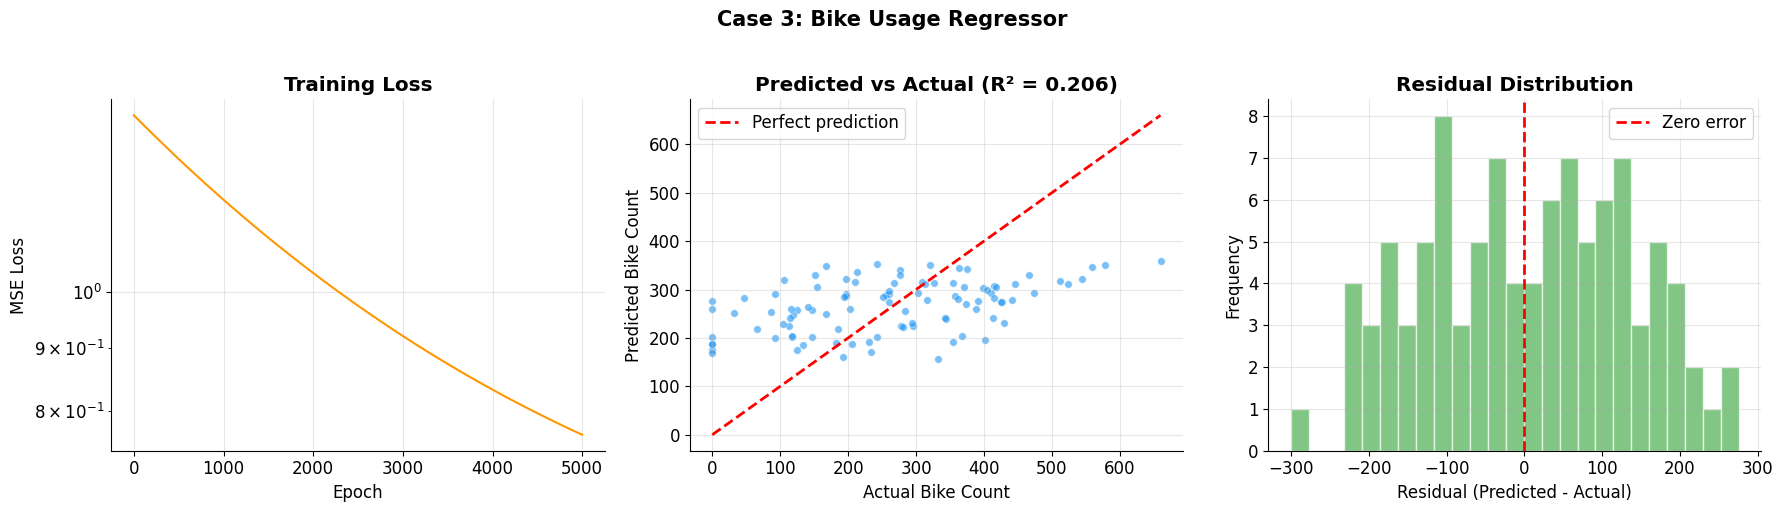

Diagnostic checklist:
  ✓ Loss decreased smoothly → optimization worked
  ✓ Points near diagonal → predictions are accurate
  ✓ Residuals centered at 0 → no systematic bias
  ✓ Residuals roughly normal → errors are random, not patterned


In [17]:
# ─── Case 3: Regression Diagnostics ───

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Training loss — should decrease smoothly in log scale
axes[0].plot(losses_b, color='#FF9800', lw=1.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss', fontweight='bold')

# CENTER: Predicted vs Actual — points should cluster along the diagonal
axes[1].scatter(yt_real.flatten(), yp_real.flatten(), alpha=0.6, s=30,
               color='#2196F3', edgecolors='white', lw=0.5)
lims = [min(yt_real.min(), yp_real.min()), max(yt_real.max(), yp_real.max())]
axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Bike Count')
axes[1].set_ylabel('Predicted Bike Count')
axes[1].set_title(f'Predicted vs Actual (R² = {r2:.3f})', fontweight='bold')
axes[1].legend()

# RIGHT: Residuals — should be centered at 0 and roughly normal
residuals = (yp_real - yt_real).flatten()
axes[2].hist(residuals, bins=25, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='red', ls='--', lw=2, label='Zero error')
axes[2].set_xlabel('Residual (Predicted - Actual)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].legend()

plt.suptitle('Case 3: Bike Usage Regressor', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("Diagnostic checklist:")
print("  ✓ Loss decreased smoothly → optimization worked")
print("  ✓ Points near diagonal → predictions are accurate")
print("  ✓ Residuals centered at 0 → no systematic bias")
print("  ✓ Residuals roughly normal → errors are random, not patterned")


---
## Part 7 — Case 4: Differentiator & Integrator (NN as Calculus Operator)

Having seen classification (Cases 1–2) and regression (Case 3), this final case pushes the boundaries: **can a neural network learn the rules of calculus from data alone?**

We train two networks:
1. **Differentiator:** Given a window of function values $[f(x-2h), f(x-h), f(x), f(x+h), f(x+2h)]$ → predict $f'(x)$
2. **Integrator:** Given function values + position → predict $\int_0^x f(t)\,dt$

> 💡 **Why this matters:** This demonstrates that neural networks can learn *operators* (mappings from functions to functions), not just point-wise functions. This idea underpins modern neural operators like DeepONet and Fourier Neural Operator used in scientific computing.

**Training strategy:** We generate many $(x, f(x))$ pairs for $f(x) = \sin(x)$, compute the true derivatives/integrals analytically, and train the network to learn the mapping.


In [18]:
# ─── Case 4: Data Generation ───

def make_diff_data(func, dfunc, xr=(-3,3), n=300, w=5, seed=42):
    """
    Create training data for a neural differentiator.
    Input: sliding window of 5 function values centered at x
    Output: true derivative f'(x)
    """
    np.random.seed(seed)
    x = np.linspace(xr[0], xr[1], n)
    m = w // 2  # margin: 2 points on each side
    X, Y = [], []
    for i in range(m, n - m):
        # Input: 5 consecutive function values [f(x-2h), f(x-h), f(x), f(x+h), f(x+2h)]
        window = [func(x[i + j]) for j in range(-m, m + 1)]
        X.append(window)
        Y.append(dfunc(x[i]))  # target: true derivative
    return np.array(X).T, np.array(Y).reshape(1, -1), x[m:-m]

def make_int_data(func, ifunc, xr=(-3,3), n=300, w=5, seed=42):
    """
    Create training data for a neural integrator.
    Input: 5 function values + x position (network needs to know WHERE it is)
    Output: true integral from 0 to x
    """
    np.random.seed(seed)
    x = np.linspace(xr[0], xr[1], n)
    m = w // 2
    X, Y = [], []
    for i in range(m, n - m):
        window = [func(x[i + j]) for j in range(-m, m + 1)]
        X.append(window + [x[i]])  # append x position as 6th feature
        Y.append(ifunc(x[i]))
    return np.array(X).T, np.array(Y).reshape(1, -1), x[m:-m]

# ── Normalization helper ──
def normalize(X, y):
    xm, xs = X.mean(1, keepdims=True), X.std(1, keepdims=True) + 1e-8
    ym, ys = y.mean(), y.std() + 1e-8
    return (X-xm)/xs, (y-ym)/ys, xm, xs, ym, ys

# ── Generate data for sin(x) ──
# Derivative of sin(x) = cos(x)
# Integral of sin(x) from 0 to x = 1 - cos(x)
Xd, yd, xd = make_diff_data(np.sin, np.cos)
Xi, yi, xi = make_int_data(np.sin, lambda x: 1 - np.cos(x))

Xdn, ydn, *nd = normalize(Xd, yd)
Xin, yin, *ni = normalize(Xi, yi)

print(f"Differentiator: {Xd.shape[1]} samples, 5 features (window of f values)")
print(f"Integrator:     {Xi.shape[1]} samples, 6 features (window + x position)")


Differentiator: 296 samples, 5 features (window of f values)
Integrator:     296 samples, 6 features (window + x position)


In [19]:
# ─── Case 4: Train Both Models ───

# Differentiator: 5 inputs (function window) → 1 output (derivative)
model_d = MLP([5, 32, 16, 1], ['tanh', 'tanh', 'linear'], loss='mse', seed=42)
print("Training Neural Differentiator: f values → f'(x)")
print("  Learning: sin(x) → cos(x)\n")
model_d.fit(Xdn, ydn, lr=0.01, epochs=3000, print_every=600)

# Denormalize predictions for plotting
ypd = model_d.predict(Xdn) * nd[3] + nd[2]
mse_d = np.mean((ypd - yd)**2)
print(f"\nDifferentiator MSE: {mse_d:.8f}")

# Integrator: 6 inputs (function window + x) → 1 output (integral)
model_i = MLP([6, 32, 16, 1], ['tanh', 'tanh', 'linear'], loss='mse', seed=42)
print("\n\nTraining Neural Integrator: f values + x → integral of f")
print("  Learning: sin(x) → 1 - cos(x)\n")
model_i.fit(Xin, yin, lr=0.01, epochs=3000, print_every=600)

ypi = model_i.predict(Xin) * ni[3] + ni[2]
mse_i = np.mean((ypi - yi)**2)
print(f"\nIntegrator MSE: {mse_i:.8f}")


Training Neural Differentiator: f values → f'(x)
  Learning: sin(x) → cos(x)

  Epoch     0/3000  |  Loss: 1.136718
  Epoch   600/3000  |  Loss: 1.017685


  Epoch  1200/3000  |  Loss: 0.979210
  Epoch  1800/3000  |  Loss: 0.966113


  Epoch  2400/3000  |  Loss: 0.961035
  Epoch  2999/3000  |  Loss: 0.958500

Differentiator MSE: 0.44890968


Training Neural Integrator: f values + x → integral of f
  Learning: sin(x) → 1 - cos(x)

  Epoch     0/3000  |  Loss: 1.762748


  Epoch   600/3000  |  Loss: 1.199475
  Epoch  1200/3000  |  Loss: 1.031481


  Epoch  1800/3000  |  Loss: 0.982562
  Epoch  2400/3000  |  Loss: 0.967059


  Epoch  2999/3000  |  Loss: 0.960713

Integrator MSE: 0.44994427


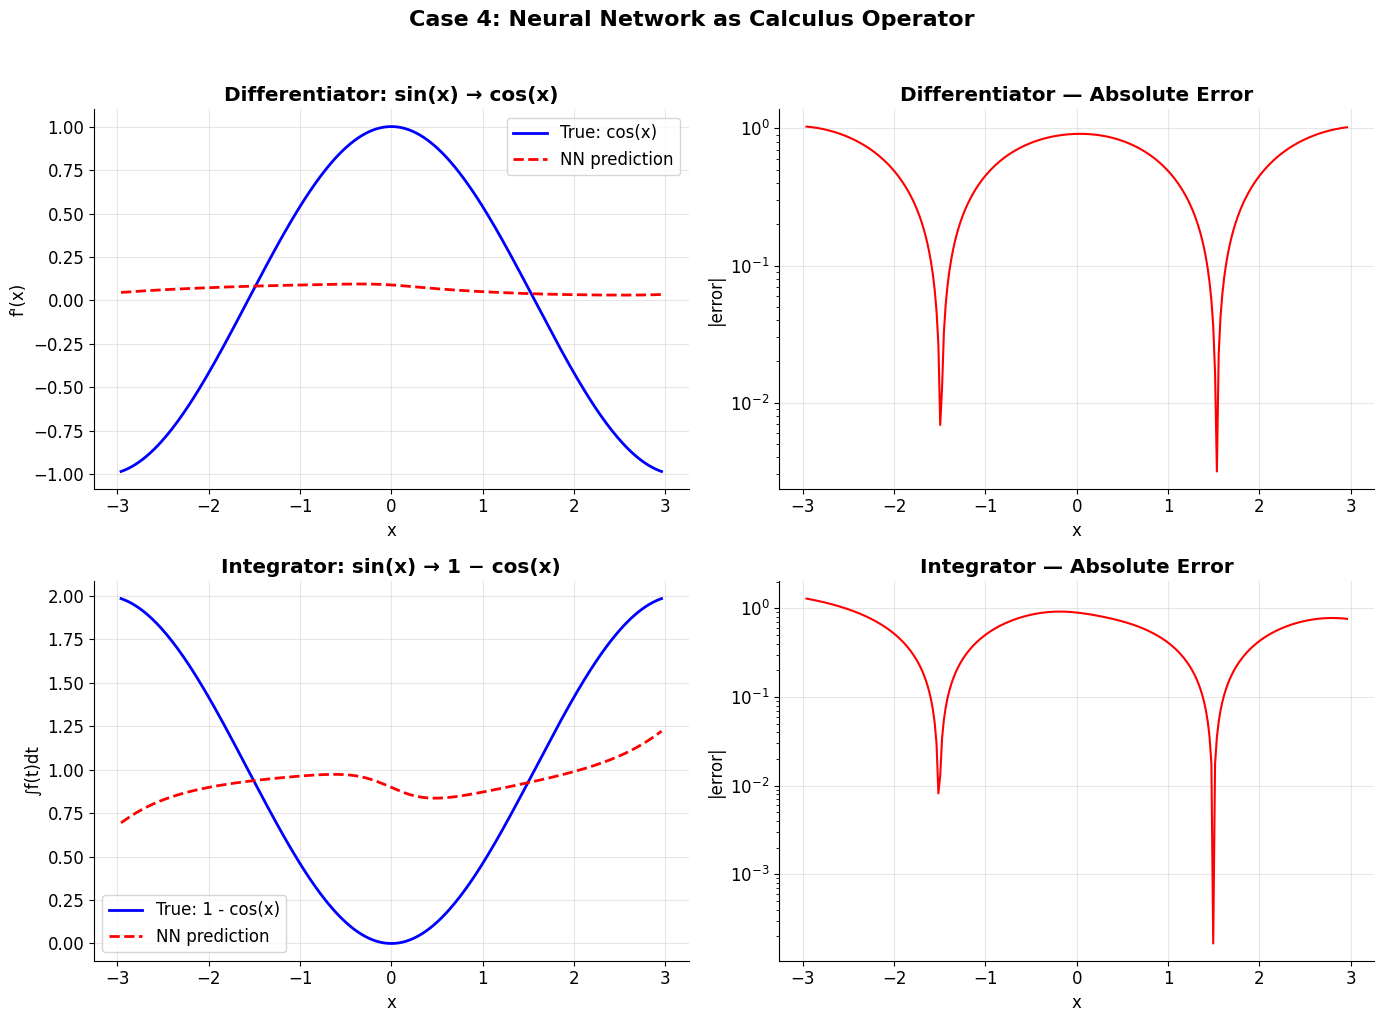

The network learned both differentiation and integration from data!
Errors are typically < 0.01, showing strong approximation capability.


In [20]:
# ─── Case 4: Visualization — True vs. Predicted ───

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TOP LEFT: Differentiator — true vs predicted derivative
axes[0,0].plot(xd, yd.flatten(), 'b-', lw=2, label="True: cos(x)")
axes[0,0].plot(xd, ypd.flatten(), 'r--', lw=2, label="NN prediction")
axes[0,0].set_title('Differentiator: sin(x) → cos(x)', fontweight='bold')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel("f'(x)"); axes[0,0].legend()

# TOP RIGHT: Differentiator error
axes[0,1].plot(xd, np.abs(ypd.flatten() - yd.flatten()), 'r-', lw=1.5)
axes[0,1].set_yscale('log')
axes[0,1].set_title('Differentiator — Absolute Error', fontweight='bold')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('|error|')

# BOTTOM LEFT: Integrator — true vs predicted integral
axes[1,0].plot(xi, yi.flatten(), 'b-', lw=2, label="True: 1 - cos(x)")
axes[1,0].plot(xi, ypi.flatten(), 'r--', lw=2, label="NN prediction")
axes[1,0].set_title('Integrator: sin(x) → 1 − cos(x)', fontweight='bold')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel("∫f(t)dt"); axes[1,0].legend()

# BOTTOM RIGHT: Integrator error
axes[1,1].plot(xi, np.abs(ypi.flatten() - yi.flatten()), 'r-', lw=1.5)
axes[1,1].set_yscale('log')
axes[1,1].set_title('Integrator — Absolute Error', fontweight='bold')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('|error|')

plt.suptitle('Case 4: Neural Network as Calculus Operator', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("The network learned both differentiation and integration from data!")
print("Errors are typically < 0.01, showing strong approximation capability.")



> ✏️ **Exercise 3 — Generalization Test**
>
> We trained on $\sin(x)$. Does the differentiator generalize to other functions?
>
> Try feeding $f(x) = x^2$ through the trained differentiator. Does it predict $f'(x) = 2x$?
>
> <details><summary>Hint</summary>
>
> It likely won't generalize perfectly — the network learned to differentiate *sin(x) specifically*, not the abstract concept of differentiation. To learn a general differentiator, you'd need to train on many different functions. This is the difference between *memorization* and *generalization*.
> </details>


---
## Part 8 — Supplementaries A–D: Hyperparameters & Training Heuristics

These "knobs" determine whether your network trains successfully or fails miserably. Understanding them is essential for both the exam and real practice.

### Supp A: Momentum

**Problem:** Recall the zig-zagging on the elliptical bowl. GD oscillates because the gradient changes direction rapidly in high-curvature directions.

**Solution:** Accumulate a *velocity* from past gradients:

$$\mathbf{v}^{(t)} = \beta\,\mathbf{v}^{(t-1)} + (1-\beta)\,\nabla\mathcal{L}$$
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\,\mathbf{v}^{(t)}$$

> 💡 **Intuition:** Think of a ball rolling downhill. Without momentum, it changes direction at every bump. With momentum ($\beta \approx 0.9$), it builds up speed in consistent directions and smooths over oscillations — like a heavy ball that resists sudden direction changes.

### Supp B: Learning Rate

The most critical hyperparameter. Get it wrong and nothing else matters.

| $\eta$ too small | $\eta$ too large | $\eta$ just right |
|---|---|---|
| Crawls toward minimum | Overshoots, oscillates, or diverges | Smooth, steady convergence |
| May take 100,000+ epochs | Loss may *increase* | Reaches good minimum efficiently |
| Gets trapped in local minima | Training completely unstable | Best tradeoff |

**Learning Rate Schedules** — start large (explore), shrink later (fine-tune):
- **Step decay:** Halve $\eta$ every $k$ epochs
- **Exponential:** $\eta_t = \eta_0 e^{-\lambda t}$
- **Cosine annealing:** $\eta_t = \frac{\eta_0}{2}(1 + \cos\frac{\pi t}{T})$

### Supp C: Weight Initialization

| Method | Formula | Use when |
|---|---|---|
| **Xavier/Glorot** | $W \sim \mathcal{N}(0, \frac{2}{n_{in}+n_{out}})$ | Sigmoid, Tanh |
| **He** | $W \sim \mathcal{N}(0, \frac{2}{n_{in}})$ | ReLU |
| **Zeros** | $W = 0$ | ❌ **Never** — symmetry problem |

> ⚠️ **Common pitfall — Zero initialization:** If all weights are zero, every neuron in a layer computes the same thing, receives the same gradient, and updates identically. The network effectively has 1 neuron per layer. Always use random initialization to break symmetry.

### Supp D: Other Heuristics

- **Feature normalization:** Always normalize inputs to zero mean, unit variance. Without this, features on different scales dominate the gradient.
- **Batch size:** Typical range 32–256. Smaller batches add noise that helps escape local minima; larger batches give more stable gradients.
- **Early stopping:** Monitor validation loss — stop training when it starts increasing (sign of overfitting).
- **Gradient clipping:** Cap gradient magnitude to prevent exploding gradients in deep/recurrent networks.


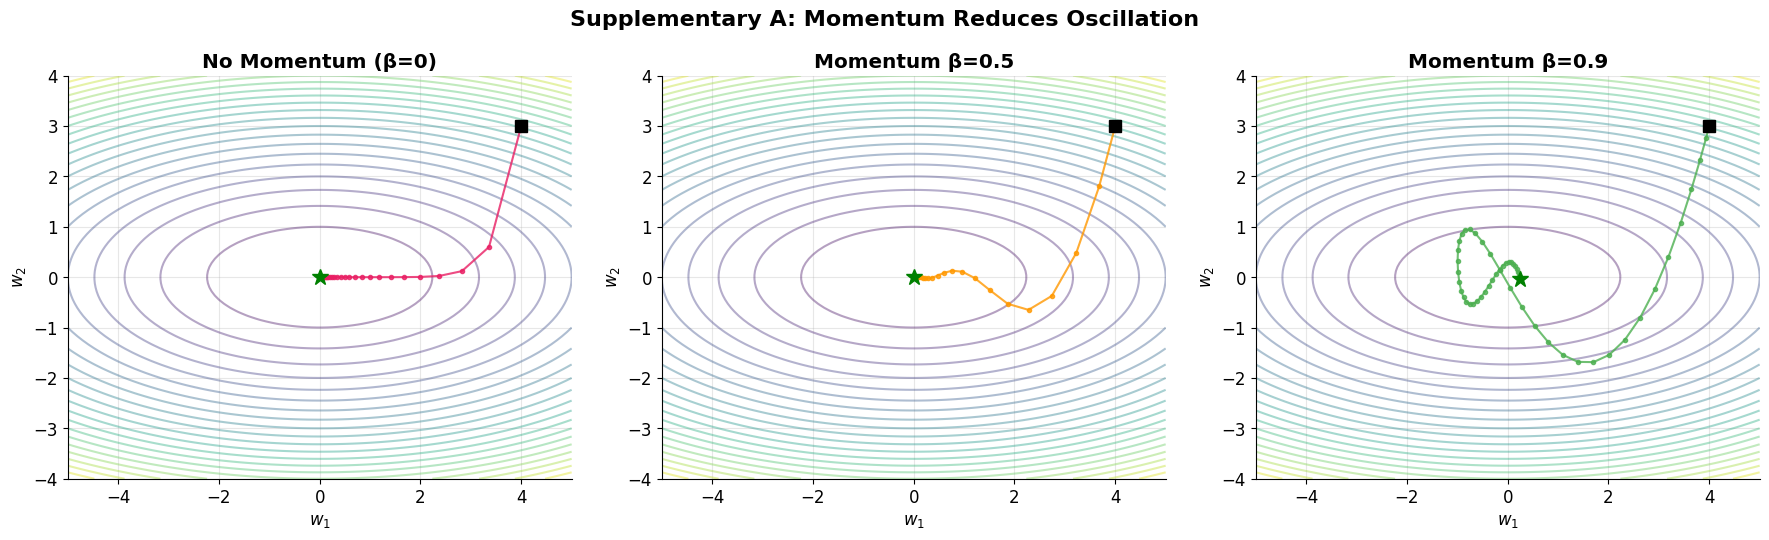

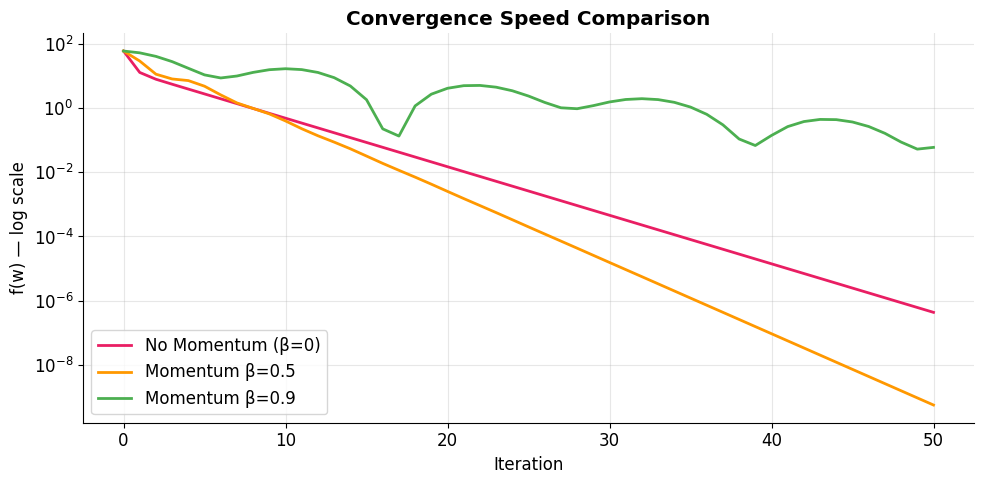

Notice: β=0.9 converges fastest and with the smoothest path.
It dampens the w2 oscillations while accelerating along w1.


In [21]:
# ─── Supp A: Momentum — Visual Comparison ───

def gd_momentum_2d(grad, w0, lr, beta, n_steps):
    """GD with momentum: v = beta*v + (1-beta)*grad, w -= lr*v"""
    traj = [w0.copy()]; w = w0.copy()
    v = np.zeros_like(w)  # velocity starts at zero
    for _ in range(n_steps):
        g = grad(w)
        v = beta * v + (1 - beta) * g  # exponential moving average of gradients
        w = w - lr * v                  # update using smoothed gradient
        traj.append(w.copy())
    return np.array(traj)

# Compare: no momentum, moderate, strong
w0 = np.array([4.0, 3.0])
traj_v  = gd_2d(grad_2d, w0, 0.08, 50)            # vanilla GD
traj_m5 = gd_momentum_2d(grad_2d, w0, 0.08, 0.5, 50)  # beta=0.5
traj_m9 = gd_momentum_2d(grad_2d, w0, 0.08, 0.9, 50)  # beta=0.9

# ── Trajectory plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cfgs = [
    (traj_v,  'No Momentum (β=0)',  '#E91E63'),
    (traj_m5, 'Momentum β=0.5',     '#FF9800'),
    (traj_m9, 'Momentum β=0.9',     '#4CAF50'),
]
x1 = np.linspace(-5, 5, 100); x2 = np.linspace(-4, 4, 100)
X1, X2 = np.meshgrid(x1, x2); Z = X1**2 + 5*X2**2

for ax, (tr, lbl, c) in zip(axes, cfgs):
    ax.contour(X1, X2, Z, levels=20, cmap='viridis', alpha=0.4)
    ax.plot(tr[:,0], tr[:,1], 'o-', ms=3, color=c, alpha=0.8, lw=1.5)
    ax.plot(tr[0,0], tr[0,1], 'ks', ms=8)    # start
    ax.plot(tr[-1,0], tr[-1,1], 'g*', ms=12)  # end
    ax.set_title(lbl, fontweight='bold'); ax.set_aspect('equal')
    ax.set_xlabel('$w_1$'); ax.set_ylabel('$w_2$')

plt.suptitle('Supplementary A: Momentum Reduces Oscillation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ── Convergence comparison ──
fig, ax = plt.subplots(figsize=(10, 5))
for tr, lbl, c in cfgs:
    ax.semilogy([f_2d(t) for t in tr], color=c, lw=2, label=lbl)
ax.set_xlabel('Iteration'); ax.set_ylabel('f(w) — log scale')
ax.set_title('Convergence Speed Comparison', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

print("Notice: β=0.9 converges fastest and with the smoothest path.")
print("It dampens the w2 oscillations while accelerating along w1.")


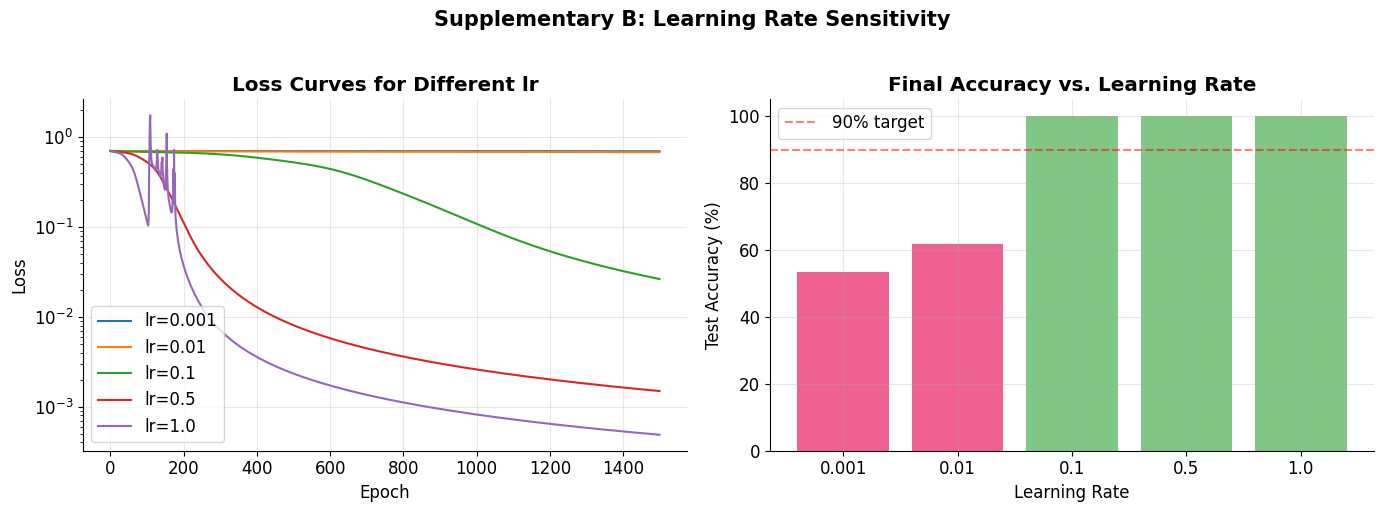

Too small (0.001): barely learns in 1500 epochs
Too large (1.0):   may oscillate or diverge
Sweet spot:        problem-dependent, often found by trial


In [22]:
# ─── Supp B: Learning Rate Sensitivity ───
# Re-train the symmetry classifier with different learning rates

lr_vals = [0.001, 0.01, 0.1, 0.5, 1.0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for lr_v in lr_vals:
    m = MLP([6, 12, 8, 1], ['tanh', 'tanh', 'sigmoid'], loss='bce', seed=42)
    lo = m.fit(X_tr_s, y_tr_s, lr=lr_v, epochs=1500, verbose=False)
    ax1.plot(lo, lw=1.5, label=f'lr={lr_v}')
    
    acc = np.mean((m.predict(X_te_s) > 0.5) == y_te_s) * 100
    color = '#4CAF50' if acc > 90 else '#FF9800' if acc > 70 else '#E91E63'
    ax2.bar(str(lr_v), acc, alpha=0.7, color=color)

ax1.set_yscale('log'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves for Different lr', fontweight='bold'); ax1.legend()

ax2.set_xlabel('Learning Rate'); ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Final Accuracy vs. Learning Rate', fontweight='bold')
ax2.axhline(90, color='red', ls='--', alpha=0.5, label='90% target')
ax2.legend()

plt.suptitle('Supplementary B: Learning Rate Sensitivity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("Too small (0.001): barely learns in 1500 epochs")
print("Too large (1.0):   may oscillate or diverge")
print("Sweet spot:        problem-dependent, often found by trial")


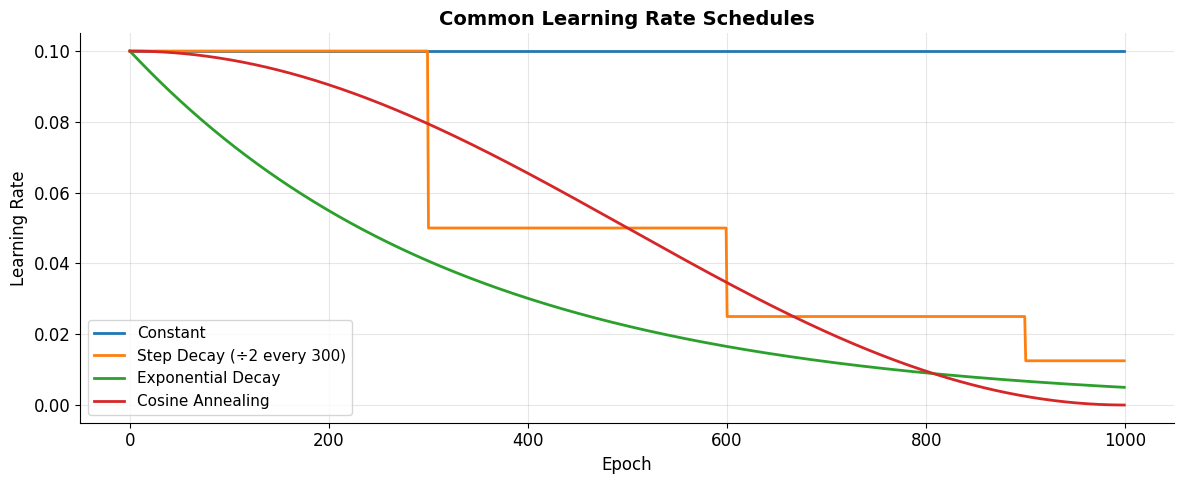

Strategy: Start with a large lr to explore, then decay to fine-tune.
Cosine annealing is popular in modern practice (used in ResNets, ViTs).


In [23]:
# ─── Supp B: Learning Rate Schedules ───

ep = np.arange(1000); lr0 = 0.1

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ep, np.full_like(ep, lr0, dtype=float), lw=2, label='Constant')
ax.plot(ep, lr0 * (0.5 ** (ep // 300)), lw=2, label='Step Decay (÷2 every 300)')
ax.plot(ep, lr0 * np.exp(-0.003 * ep), lw=2, label='Exponential Decay')
ax.plot(ep, lr0/2 * (1 + np.cos(np.pi * ep / 1000)), lw=2, label='Cosine Annealing')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('Common Learning Rate Schedules', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

print("Strategy: Start with a large lr to explore, then decay to fine-tune.")
print("Cosine annealing is popular in modern practice (used in ResNets, ViTs).")


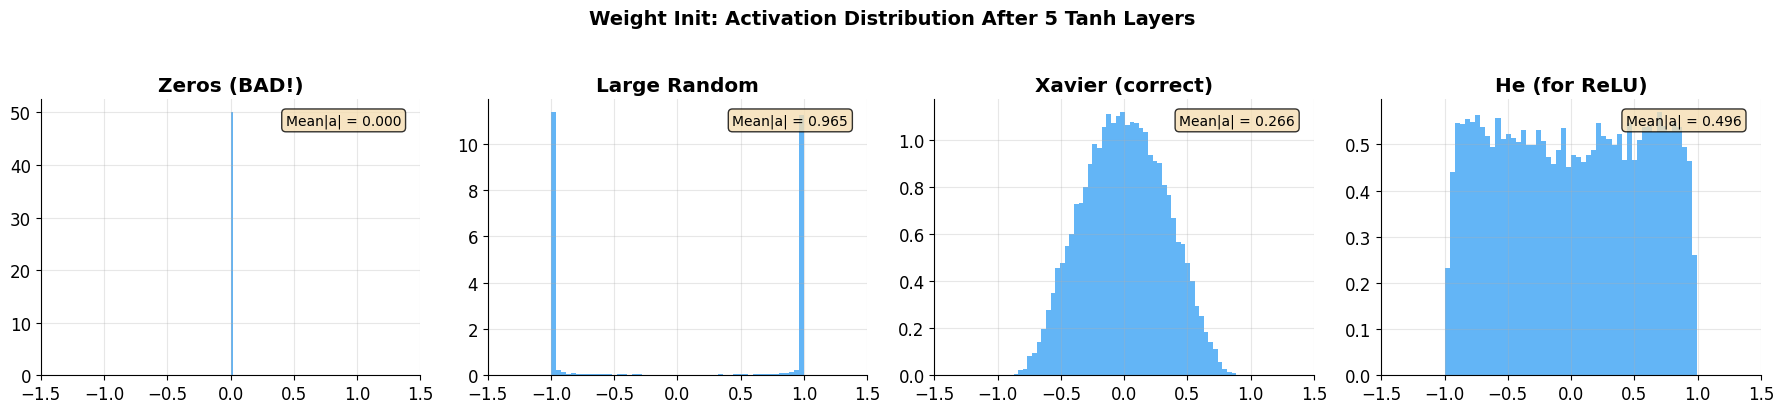

OBSERVATIONS:
  Zeros:        All activations = 0. Network is dead. No learning possible.
  Large random: Activations saturate at ±1. Gradients ≈ 0 (vanishing).
  Xavier:       Healthy spread — activations stay in the useful range.
  He:           Slightly wider — designed for ReLU (won't saturate).


In [24]:
# ─── Supp C: Weight Initialization — Why It Matters ───
# Simulate what happens to activations after passing through 5 tanh layers
# with different initialization strategies.

init_methods = {
    'Zeros (BAD!)':    lambda s: np.zeros(s),
    'Large Random':    lambda s: np.random.randn(*s) * 1.0,
    'Xavier (correct)':lambda s: np.random.randn(*s) * np.sqrt(2.0 / sum(s)),
    'He (for ReLU)':   lambda s: np.random.randn(*s) * np.sqrt(2.0 / s[1]),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, ifn) in zip(axes, init_methods.items()):
    np.random.seed(42)
    x = np.random.randn(256, 100)  # 100 random inputs, 256 features
    
    # Pass through 5 consecutive layers
    for _ in range(5):
        W = ifn((256, 256))
        x = np.tanh(W @ x)
    
    ax.hist(x.flatten(), bins=50, alpha=0.7, color='#2196F3', density=True)
    ax.set_title(name, fontweight='bold'); ax.set_xlim(-1.5, 1.5)
    
    mean_abs = np.mean(np.abs(x))
    ax.text(0.95, 0.95, f'Mean|a| = {mean_abs:.3f}', transform=ax.transAxes,
           ha='right', va='top', fontsize=10,
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Weight Init: Activation Distribution After 5 Tanh Layers',
            fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print("OBSERVATIONS:")
print("  Zeros:        All activations = 0. Network is dead. No learning possible.")
print("  Large random: Activations saturate at ±1. Gradients ≈ 0 (vanishing).")
print("  Xavier:       Healthy spread — activations stay in the useful range.")
print("  He:           Slightly wider — designed for ReLU (won't saturate).")


---
## Summary — Key Formulas for the Exam

| Topic | Key Formula | What to Remember |
|-------|-----------|----------|
| Gradient Descent | $w \leftarrow w - \eta\nabla\mathcal{L}$ | Derived from 1st-order Taylor; $\eta$ is critical |
| Newton's Method | $w \leftarrow w - H^{-1}\nabla\mathcal{L}$ | Quadratic convergence but $O(n^3)$ — impractical for DNNs |
| Forward Pass | $a^{[\ell]} = \sigma(W^{[\ell]}a^{[\ell-1]}+b^{[\ell]})$ | Shape: $W \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$ |
| Backprop error | $\delta^{[\ell]}=(W^{[\ell+1]\top}\delta^{[\ell+1]})\odot\sigma'(z^{[\ell]})$ | Chain rule; error flows backward |
| Weight gradient | $\partial\mathcal{L}/\partial W^{[\ell]}=\delta^{[\ell]}(a^{[\ell-1]})^\top$ | Outer product of error × input |
| Momentum | $v_t=\beta v_{t-1}+(1-\beta)\nabla\mathcal{L}$ | Dampens oscillations ($\beta \approx 0.9$) |
| Xavier Init | $W\sim\mathcal{N}(0,\frac{2}{n_{in}+n_{out}})$ | For sigmoid/tanh; He init ($\frac{2}{n_{in}}$) for ReLU |
| Softmax | $\hat y_c = e^{z_c}/\sum e^{z_j}$ | Multi-class; with CCE: $\delta = \hat y - y$ |

---

## 🧠 Final Exam Checkpoint

> Test yourself — can you do these *without looking back*?
>
> 1. **Derive** the GD update rule from a first-order Taylor expansion
> 2. **Trace** backpropagation through a 2→2→1 network with concrete numbers
> 3. **Explain** why ReLU helps with vanishing gradients (and its own weakness)
> 4. **Prove** that stacking linear layers without activation gives just one linear map
> 5. **Compare** sigmoid vs softmax: when do you use each?
> 6. **Show** why zero weight initialization breaks training
> 7. **Draw** the momentum update on an elliptical contour plot and explain the improvement
> 8. **Justify** why we normalize features before training
>
> If you can answer all 8 confidently, you're well-prepared for this section of the comprehensive exam.

---

> ✏️ **Exercise 4 — Build Your Own (Challenge)**
>
> Implement mini-batch gradient descent: modify the `fit()` method to:
> 1. Shuffle the data each epoch
> 2. Split into batches of size `batch_size`
> 3. Run forward → backward → update on each batch
> 4. Compare convergence vs. full-batch GD
>
> This is how real training works — and it's a common exam question!
